<h1>EXPLORATORY DATA ANALYSIS - HOME CREDIT DEFAULT RISK</h1>

# Overview

The dataset provided contains a vast number of details about the borrower. It is separated into several relational tables, which contain applicants’ static data such as their gender, age, number of family members, occupation, and other necessary fields, applicant’s previous credit history obtained from the credit bureau department, and the applicant’s past credit history within the Home Credit Group itself. The dataset is an imbalanced dataset, where the negative class dominates the positive class, as there are only a few number of defaulters among all the applicants.

## Brief Description of Each File in the Dataset

`application_train.csv` / `application_test.csv`

The **main tables**. Each row is one loan application.
- `application_train` has the target column: `TARGET` (1 = defaulted, 0 = repaid)
- Contains ~120 features: client demographics (age, gender, education, family status), loan info (amount, annuity, credit type), social/economic indicators (income, occupation, housing), and flags/counts of various documents provided
- `application_test` is identical minus `TARGET`. 

---

## Supplementary Files (all join back via `SK_ID_CURR`)

`bureau.csv`

Previous **credits from other financial institutions**, as reported to the Credit Bureau.
- One row per previous credit (a client can have many)
- Fields: credit type, currency, active/closed status, credit amount, amount overdue, days credit open/closed, etc.

`bureau_balance.csv`

**Monthly balance snapshots** of each bureau credit.
- Joins to `bureau.csv` via `SK_ID_BUREAU`
- One row per month per bureau credit
- Fields: `MONTHS_BALANCE` (relative month), `STATUS` (0–5 = DPD buckets, C = closed, X = unknown)

---

`previous_application.csv`

All **prior loan applications** at Home Credit (not other institutions).
- One row per previous application
- Fields: previous loan purpose, contract type, application/decision/disbursement dates, requested vs. approved vs. actual amounts, whether the client received the loan, reason for rejection, etc.

`POS_CASH_balance.csv`

Monthly snapshots of **point-of-sale and cash loans** the client had previously at Home Credit.
- Joins via `SK_ID_PREV`
- Fields: months balance, contract status, DPD, number of instalments

`installments_payments.csv`

**Payment history** for previous Home Credit loans, basically what was owed vs. what was actually paid and when.
- Joins via `SK_ID_PREV`
- Fields: instalment number, due date, payment date, amount due, amount paid

`credit_card_balance.csv`

Monthly snapshots of **credit card balances** for previous Home Credit credit cards.
- Joins via `SK_ID_PREV`
- Fields: balance, credit limit, drawings (ATM, non-ATM), payment amount, DPD, min. installment

---

## Auxiliary File

`HomeCredit_columns_description.csv`

A **data dictionary** that maps every column name across all files to a plain-English description. 

---

### Relationship Map

```
application_train/test  (SK_ID_CURR)
    ├── bureau             (SK_ID_CURR → SK_ID_BUREAU)
    │       └── bureau_balance      (SK_ID_BUREAU)
    ├── previous_application       (SK_ID_CURR → SK_ID_PREV)
    │       ├── POS_CASH_balance        (SK_ID_PREV)
    │       ├── installments_payments   (SK_ID_PREV)
    │       └── credit_card_balance     (SK_ID_PREV)
```

# 1. Import Libraries

In [1]:
from pathlib import Path 
import chardet 

import numpy as np 
import pandas as pd 

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

# 2. Define Helper Functions

In [2]:
def load_data(file_path, **kwargs):
    with open(file_path, "rb") as f:
        raw = f.read(10000)  

    encoding = chardet.detect(raw)["encoding"]

    return pd.read_csv(file_path, encoding=encoding, **kwargs)

In [3]:
def plot_target_distribution(train, target_col='TARGET'):
    counts = train[target_col].value_counts().sort_index()

    plt.figure(figsize=(6, 6))

    plt.pie(
        counts,
        labels=[f'Class {i}\n(n={v})' for i, v in zip(counts.index, counts.values)],
        autopct='%1.1f%%',
        startangle=90
    )

    plt.title('Target Distribution')
    plt.tight_layout()
    plt.show()

In [4]:
def missing_summary(df, label="DataFrame"):
    total   = df.isnull().sum()
    percent = (total / len(df) * 100).round(2)
    summary = pd.DataFrame({"missing_count": total, "missing_pct": percent})
    summary = summary[summary.missing_count > 0].sort_values("missing_pct", ascending=False)
    print(f"\n{label}: {summary.shape[0]} columns have missing values")
    
    return summary

In [5]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()

        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1

        n_out = ((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum()
        rows.append({"feature": col, "Q1": Q1, "Q3": Q3, "IQR": IQR,
                     "n_outliers": n_out, "outlier_pct": round(n_out / len(s) * 100, 2)})
        
    return pd.DataFrame(rows).set_index("feature").sort_values("outlier_pct", ascending=False)

# 3. Exploratory Data Analysis

## 3.1. Train vs Test

In [6]:
test = load_data('data/application_test.csv')
train = load_data('data/application_train.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (307511, 122)
Test shape: (48744, 121)


In [7]:
train_missing = missing_summary(train, "train")
test_missing  = missing_summary(test,  "test")

display(train_missing.head(10))


train: 67 columns have missing values

test: 64 columns have missing values


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


In [8]:
display(test_missing.head(10))

,missing_count,missing_pct
COMMONAREA_AVG,33495,68.72
COMMONAREA_MODE,33495,68.72
COMMONAREA_MEDI,33495,68.72
NONLIVINGAPARTMENTS_AVG,33347,68.41
NONLIVINGAPARTMENTS_MODE,33347,68.41
NONLIVINGAPARTMENTS_MEDI,33347,68.41
FONDKAPREMONT_MODE,32797,67.28
LIVINGAPARTMENTS_MODE,32780,67.25
LIVINGAPARTMENTS_AVG,32780,67.25
LIVINGAPARTMENTS_MEDI,32780,67.25


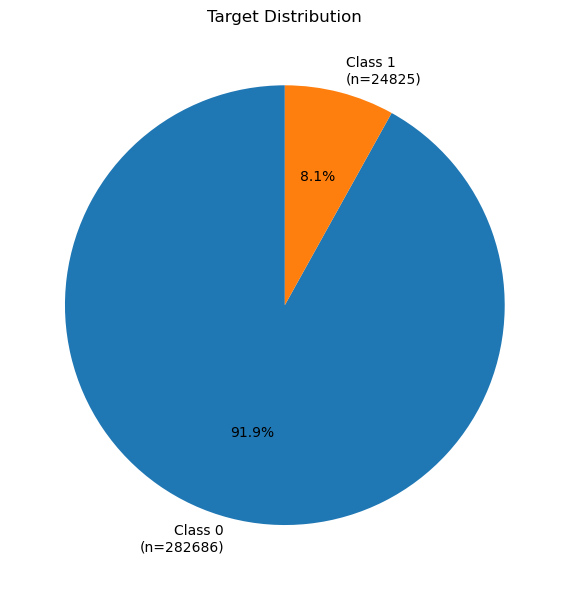

In [9]:
plot_target_distribution(train, 'TARGET')

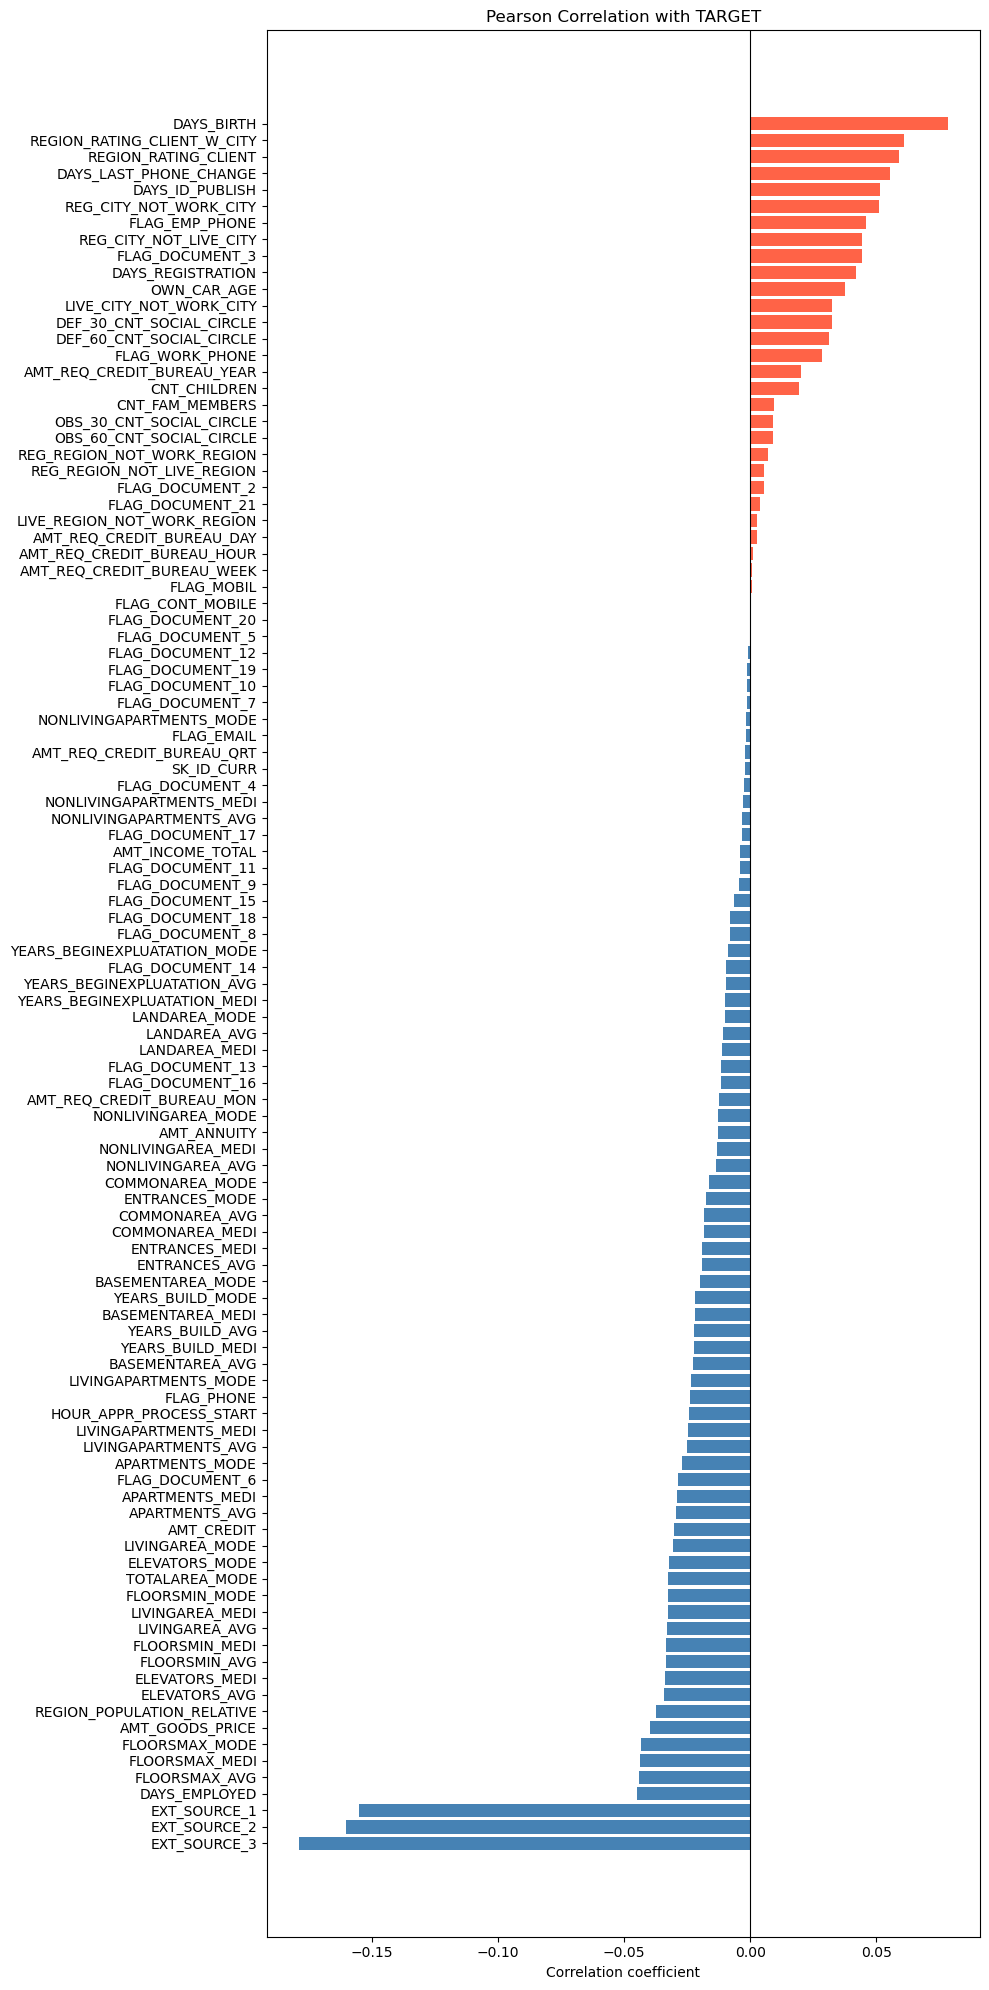

In [10]:
# Correlation with target 
num_cols  = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
feat_num  = [c for c in num_cols if c != "TARGET"]

target_corr = (
    train[feat_num + ["TARGET"]]
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 20))
colors = ["tomato" if v > 0 else "steelblue" for v in target_corr]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with TARGET")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

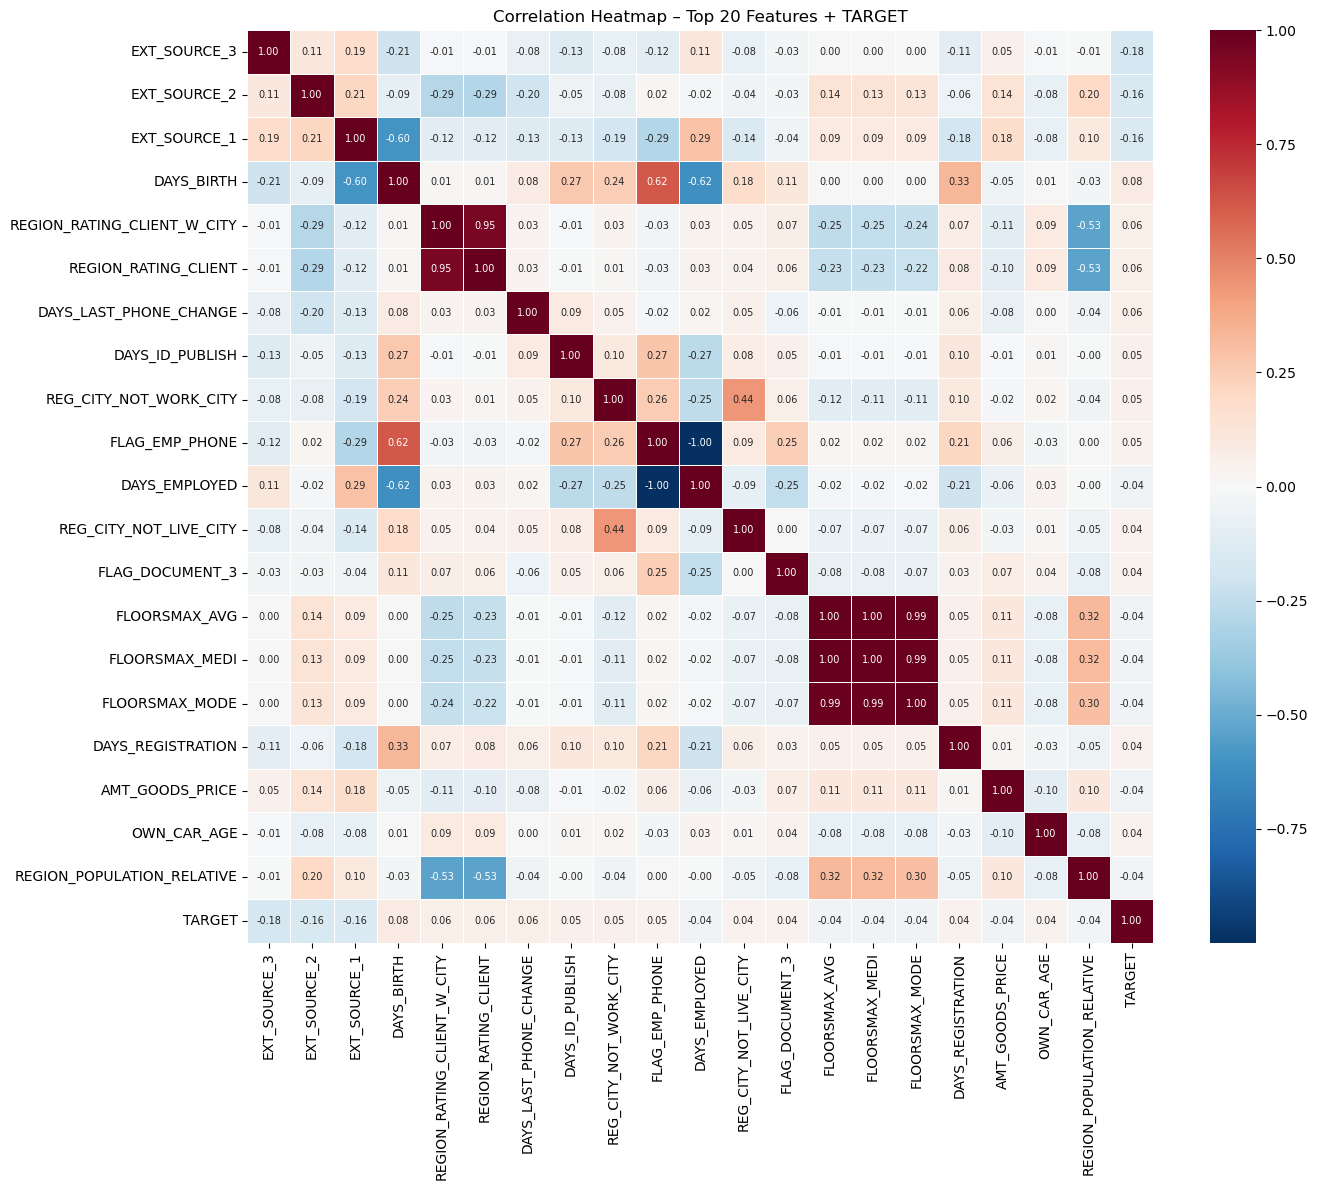

In [11]:
# Heatmap of top correlated numeric features
top_corr_features = target_corr.abs().nlargest(20).index.tolist() + ["TARGET"]
corr_matrix = train[top_corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    linewidths=0.5, ax=ax, annot_kws={"size": 7}
)
ax.set_title("Correlation Heatmap – Top 20 Features + TARGET")
plt.tight_layout()
plt.show()

In [12]:
outlier_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
                "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

display(iqr_outlier_summary(train, outlier_cols))

,Q1,Q3,IQR,n_outliers,outlier_pct
feature,,,,,
AMT_GOODS_PRICE,238500.000000,679500.000000,441000.000000,14728,4.79
AMT_INCOME_TOTAL,112500.000000,202500.000000,90000.000000,14035,4.56
AMT_ANNUITY,16524.000000,34596.000000,18072.000000,7504,2.44
AMT_CREDIT,270000.000000,808650.000000,538650.000000,6562,2.13
EXT_SOURCE_1,0.334007,0.675053,0.341045,0,0.00
EXT_SOURCE_2,0.392457,0.663617,0.271160,0,0.00
EXT_SOURCE_3,0.370650,0.669057,0.298407,0,0.00


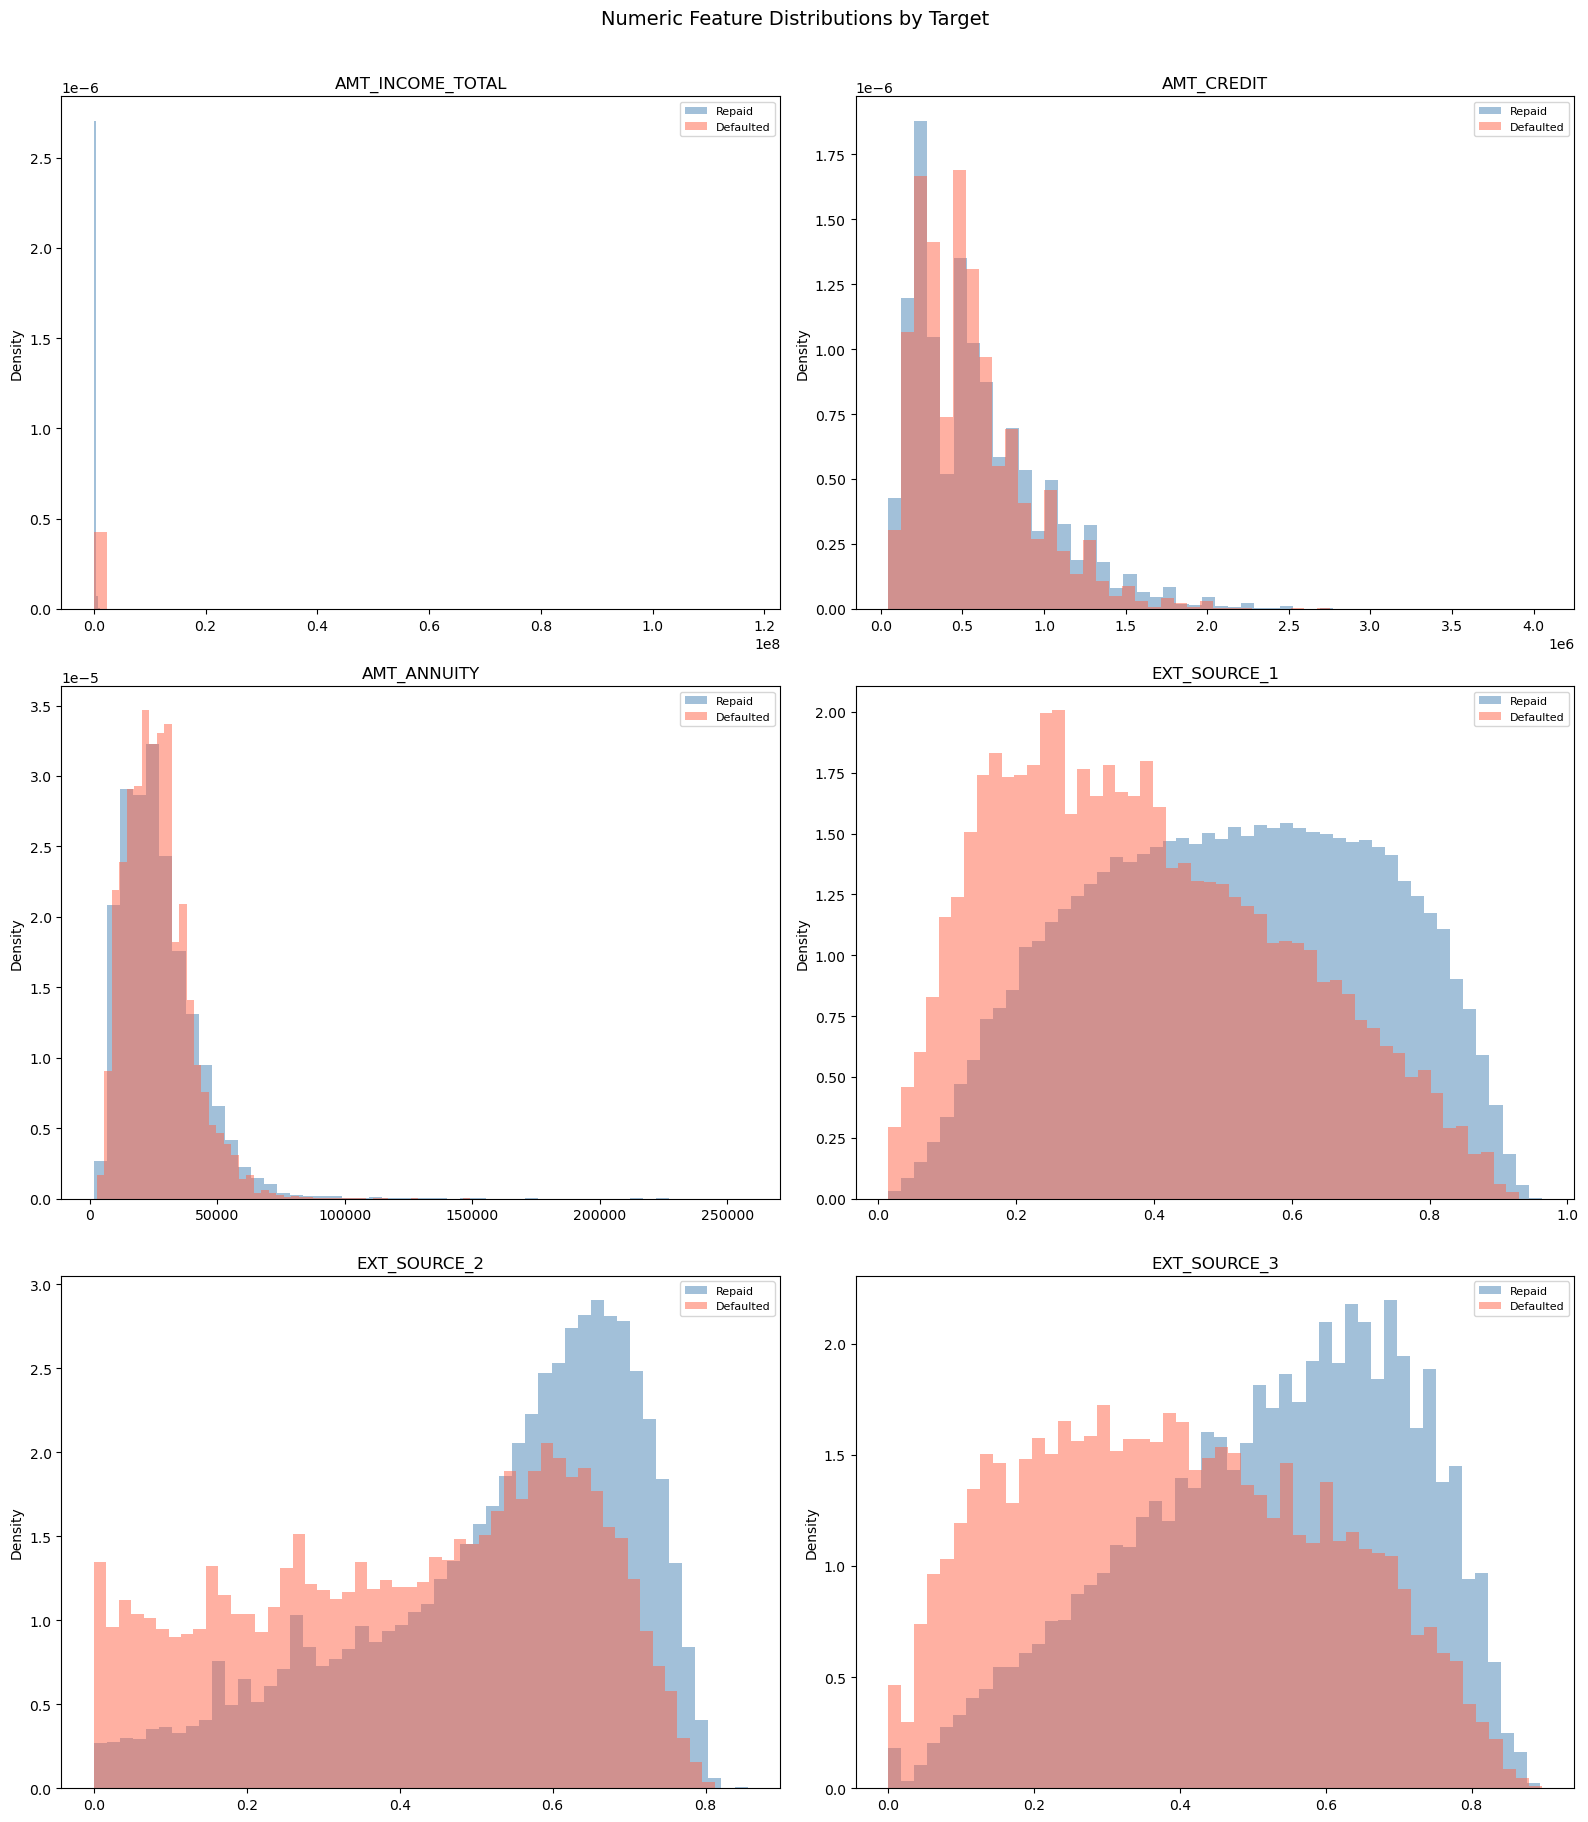

In [13]:
plot_features = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"
]   # Key numeric features 

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# Distribution plots of numeric features per default rate 
for i, col in enumerate(plot_features):
    for target_val, color, label in [(0, "steelblue", "Repaid"), (1, "tomato", "Defaulted")]:
        data = train.loc[train["TARGET"] == target_val, col].dropna()
        axes[i].hist(data, bins=50, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel("Density")

plt.suptitle("Numeric Feature Distributions by Target", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

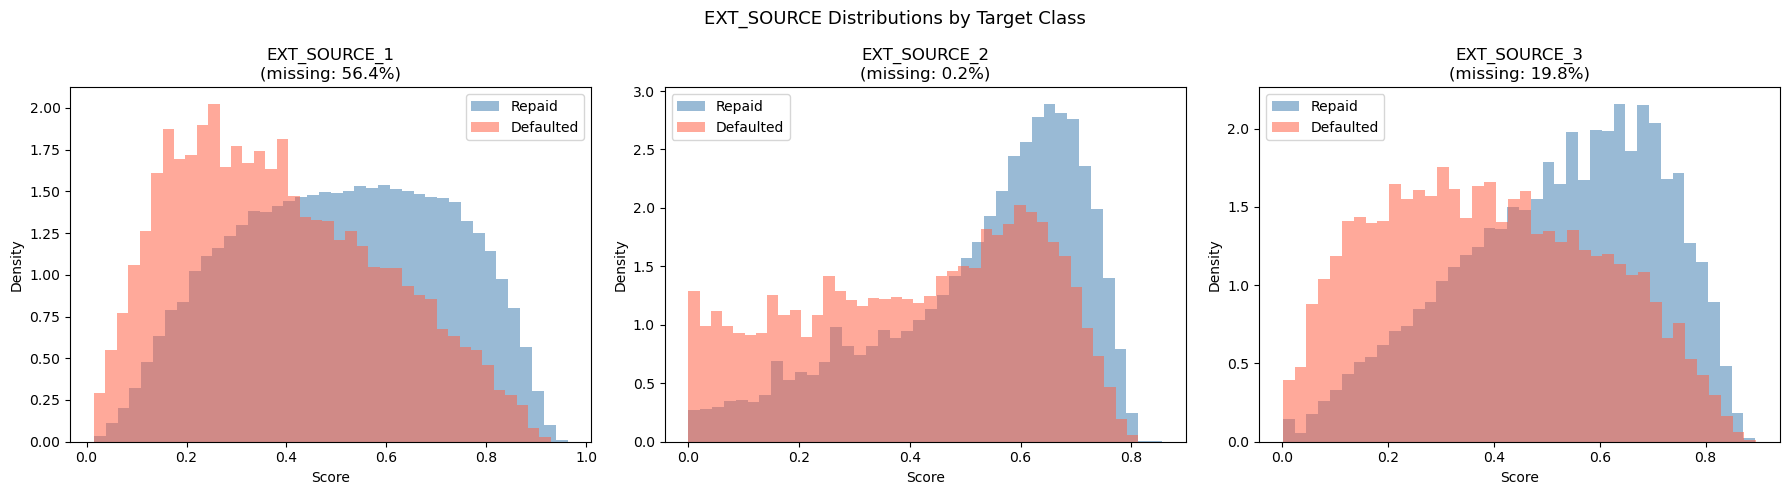

EXT_SOURCE_1: Repaid=0.511  Defaulted=0.387  Δ=0.124
EXT_SOURCE_2: Repaid=0.523  Defaulted=0.411  Δ=0.113
EXT_SOURCE_3: Repaid=0.521  Defaulted=0.391  Δ=0.130


In [14]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(ext_cols):
    for target_val, color, label in [(0, "steelblue", "Repaid"), (1, "tomato", "Defaulted")]:
        data = train.loc[train["TARGET"] == target_val, col].dropna()
        axes[i].hist(data, bins=40, alpha=0.55, color=color, label=label, density=True)
    axes[i].set_title(f"{col}\n(missing: {train[col].isnull().mean()*100:.1f}%)")
    axes[i].legend()
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Density")

plt.suptitle("EXT_SOURCE Distributions by Target Class", fontsize=13)
plt.tight_layout()
plt.show()

# Mean score by class
for col in ext_cols:
    grp = train.groupby("TARGET")[col].mean()
    print(f"{col}: Repaid={grp[0]:.3f}  Defaulted={grp[1]:.3f}  Δ={grp[0]-grp[1]:.3f}")

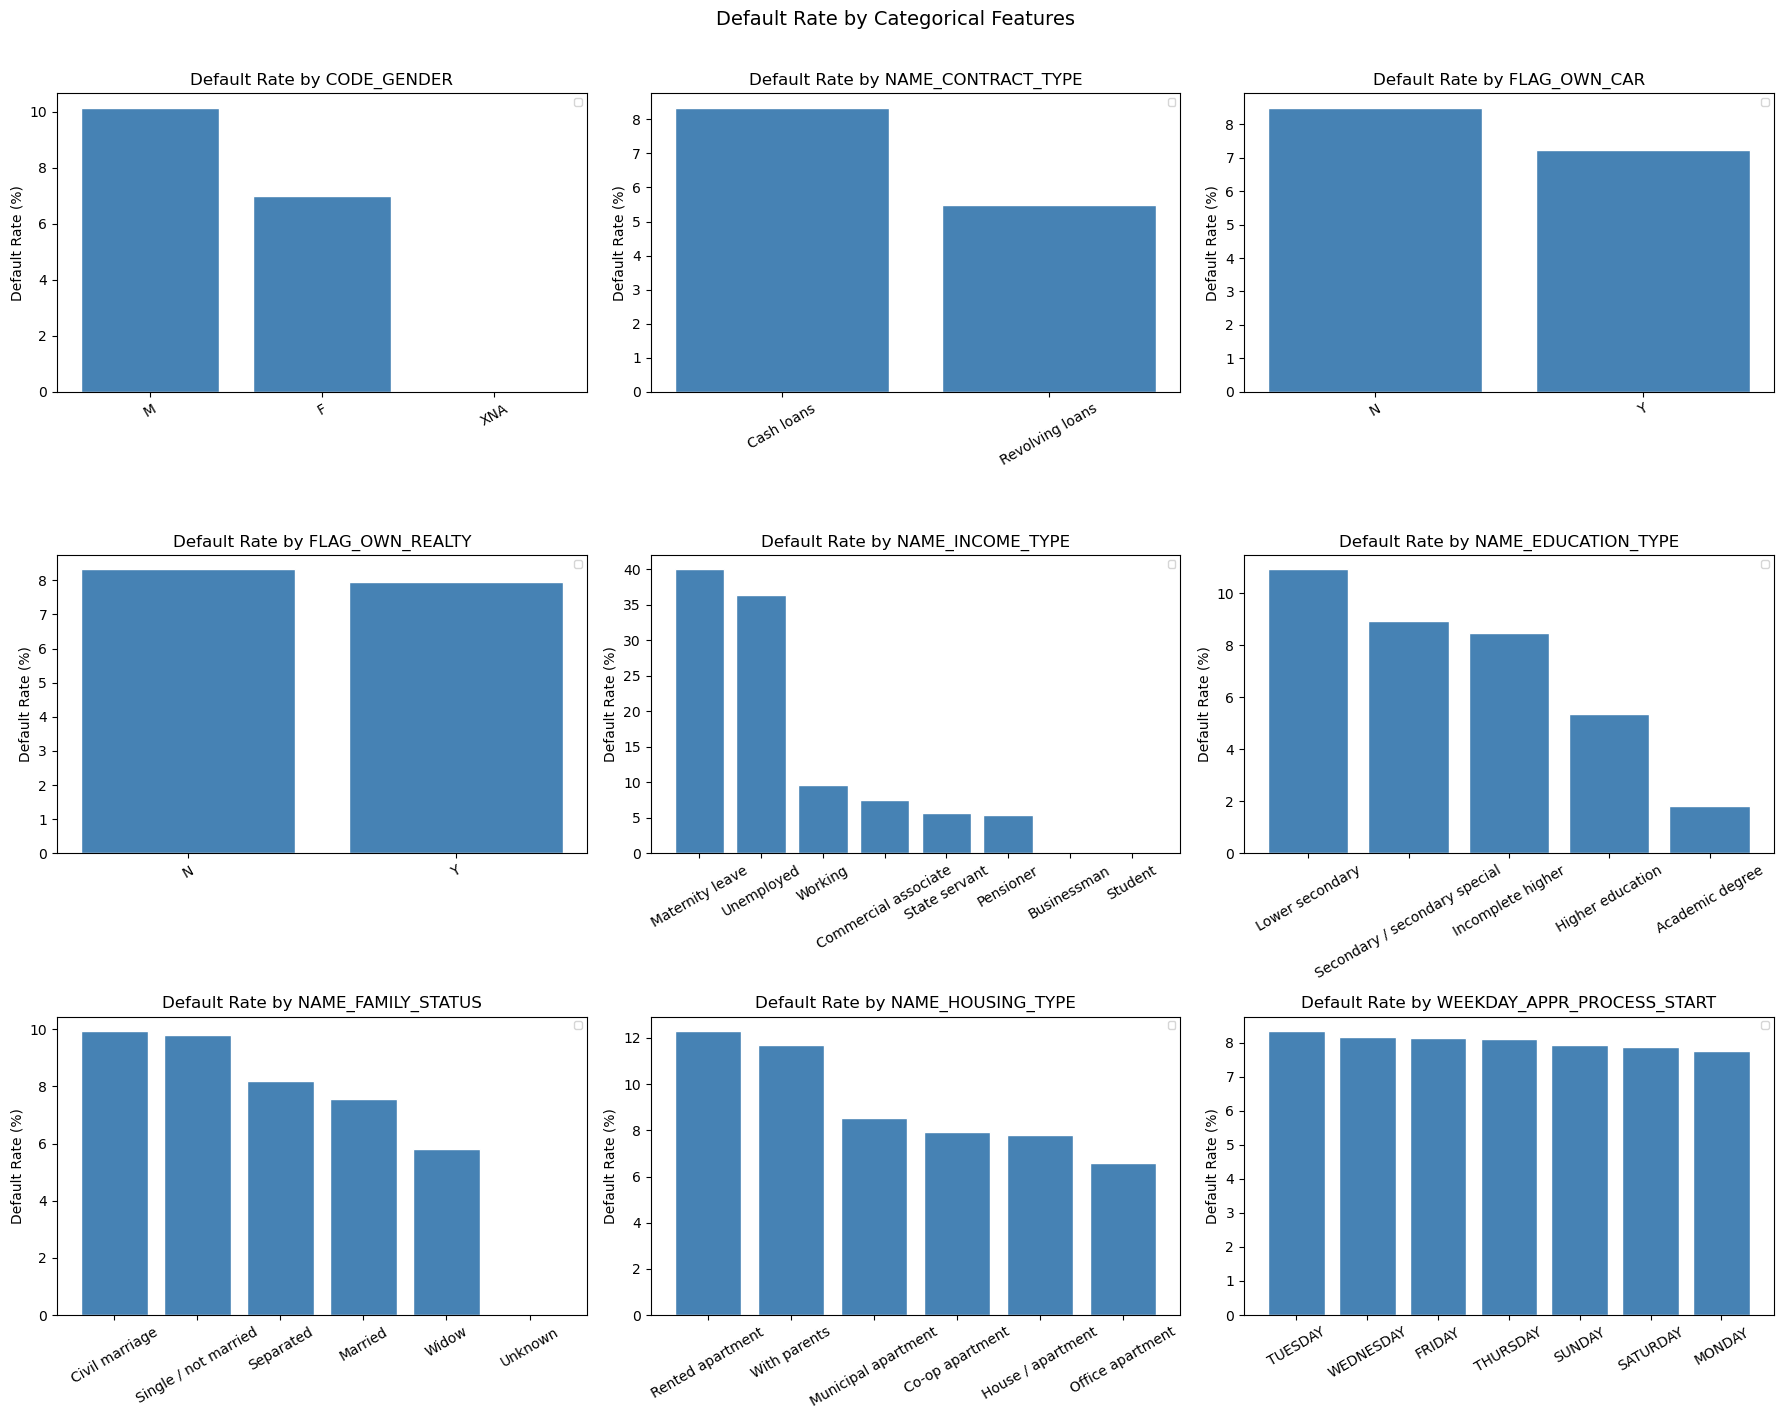

In [15]:
# Default rate per category for key categorical features
key_cat = [
    "CODE_GENDER", "NAME_CONTRACT_TYPE", "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "WEEKDAY_APPR_PROCESS_START"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    default_rate = (
        train.groupby(col)["TARGET"].mean()
              .sort_values(ascending=False)
              .reset_index()
    )
    axes[i].bar(default_rate[col], default_rate["TARGET"] * 100, color="steelblue", edgecolor="white")
    axes[i].set_title(f"Default Rate by {col}")
    axes[i].set_ylabel("Default Rate (%)")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].legend(fontsize=7)

plt.suptitle("Default Rate by Categorical Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Number of document flag columns: 20


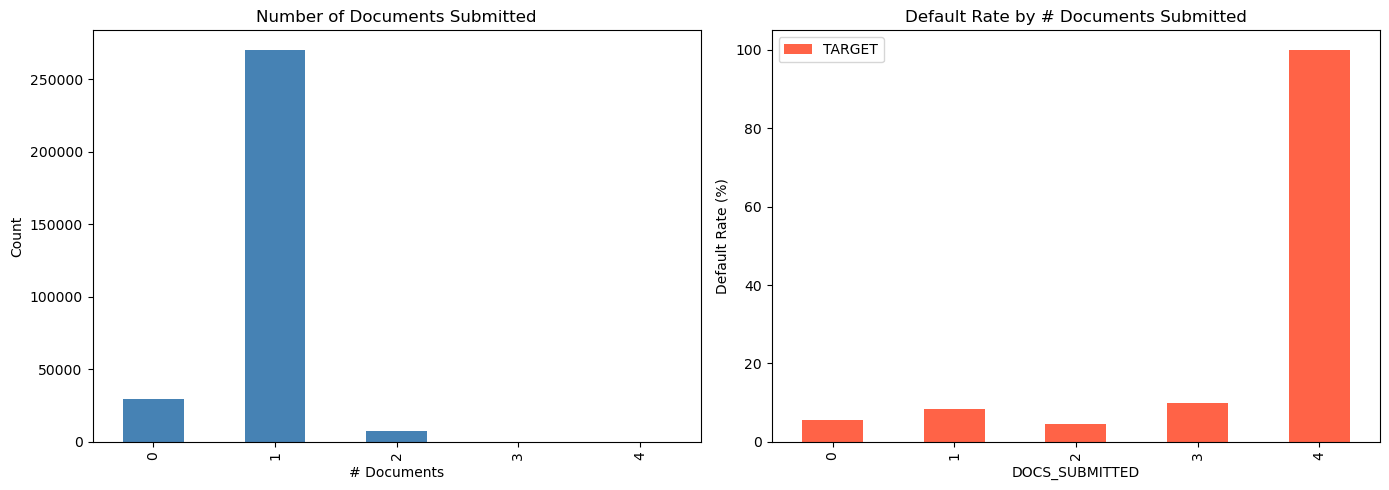

In [16]:
doc_cols = [c for c in train.columns if c.startswith("FLAG_DOCUMENT_")]
print(f"Number of document flag columns: {len(doc_cols)}")

train["DOCS_SUBMITTED"] = train[doc_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of docs submitted
train["DOCS_SUBMITTED"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Number of Documents Submitted")
axes[0].set_xlabel("# Documents")
axes[0].set_ylabel("Count")

# Default rate by docs submitted
default_by_docs = train.groupby("DOCS_SUBMITTED")["TARGET"].mean() * 100
default_by_docs.plot(kind="bar", ax=axes[1], color="tomato")
axes[1].set_title("Default Rate by # Documents Submitted")
axes[1].set_ylabel("Default Rate (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Key Findings

| Finding | Detail |
|---|---|
| **Class imbalance** | ~8% default rate. |
| **EXT_SOURCE_1/2/3** | Strongest predictors; defaulters have significantly lower scores. |
| **Missing values** | Several columns > 50% missing (OWN_CAR_AGE, EXT_SOURCE_1, etc.) → impute or drop. |
| **CODE_GENDER XNA** | Small category; merge with most similar group or flag separately. |
| **Document flags** | Submitting 0 documents correlates with higher default risk. |

## 3.2 Bureau and Bureau Balance 

In [17]:
bureau = load_data('data/bureau.csv')
bureau_bal = load_data('data/bureau_balance.csv')

print("bureau shape:", bureau.shape)
print("bureau_balance shape:", bureau_bal.shape)
print()
print("Unique SK_ID_CURR in bureau:", bureau['SK_ID_CURR'].nunique())
print("Unique SK_ID_BUREAU in bureau:", bureau['SK_ID_BUREAU'].nunique())
print("Unique SK_ID_BUREAU in bureau_balance:", bureau_bal['SK_ID_BUREAU'].nunique())

bureau shape: (1716428, 17)
bureau_balance shape: (27299925, 3)

Unique SK_ID_CURR in bureau: 305811
Unique SK_ID_BUREAU in bureau: 1716428
Unique SK_ID_BUREAU in bureau_balance: 817395


In [18]:
# How many bureau records per applicant?
credits_per_applicant = bureau.groupby('SK_ID_CURR').size()
print("Bureau credits per applicant:")
print(credits_per_applicant.describe().round(2))

Bureau credits per applicant:
count    305811.00
mean          5.61
std           4.43
min           1.00
25%           2.00
50%           4.00
75%           8.00
max         116.00
dtype: float64


In [19]:
bureau_missing = missing_summary(bureau, "bureau")
bureau_bal_missing = missing_summary(bureau_bal, "bureau_balance")

display(bureau_missing)
display(bureau_bal_missing)


bureau: 7 columns have missing values

bureau_balance: 0 columns have missing values


,missing_count,missing_pct
AMT_ANNUITY,1226791,71.47
AMT_CREDIT_MAX_OVERDUE,1124488,65.51
DAYS_ENDDATE_FACT,633653,36.92
AMT_CREDIT_SUM_LIMIT,591780,34.48
AMT_CREDIT_SUM_DEBT,257669,15.01
DAYS_CREDIT_ENDDATE,105553,6.15
AMT_CREDIT_SUM,13,0.00


,missing_count,missing_pct


In [20]:
# Aggregate bureau features per applicant
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_COUNT          = ('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_COUNT   = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT   = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_OVERDUE_MAX    = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_OVERDUE_MEAN   = ('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_AMT_CREDIT_SUM = ('AMT_CREDIT_SUM', 'sum'),
    BUREAU_AMT_DEBT_SUM   = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_AMT_OVERDUE    = ('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    BUREAU_DAYS_CREDIT_MEAN  = ('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_ENDDATE_MEAN = ('DAYS_CREDIT_ENDDATE', 'mean'),
).reset_index()

bureau_agg['BUREAU_DEBT_RATIO'] = (
    bureau_agg['BUREAU_AMT_DEBT_SUM'] / (bureau_agg['BUREAU_AMT_CREDIT_SUM'] + 1)
)

train_bureau = train[['SK_ID_CURR', 'TARGET']].merge(bureau_agg, on='SK_ID_CURR', how='left')

print("train_bureau shape:", train_bureau.shape)
print("Applicants with NO bureau record:", train_bureau['BUREAU_COUNT'].isnull().sum())

train_bureau shape: (307511, 13)
Applicants with NO bureau record: 44020


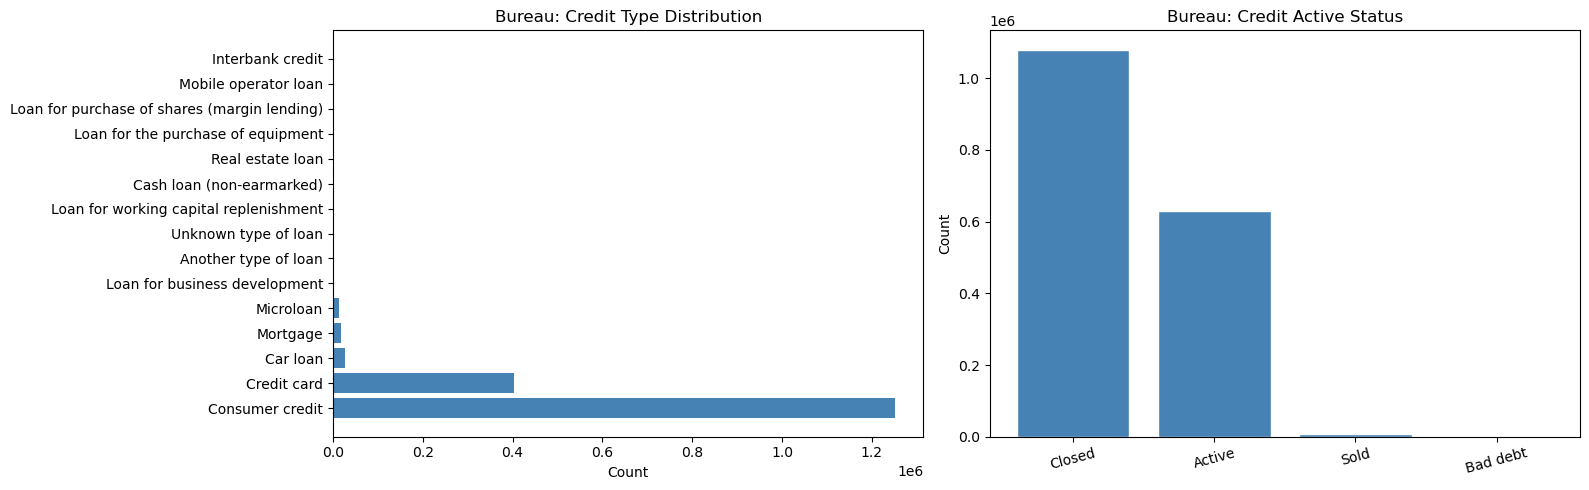

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Credit type distribution
credit_type_counts = bureau['CREDIT_TYPE'].value_counts()
axes[0].barh(credit_type_counts.index, credit_type_counts.values, color='steelblue')
axes[0].set_title('Bureau: Credit Type Distribution')
axes[0].set_xlabel('Count')

# Credit active status distribution
credit_active_counts = bureau['CREDIT_ACTIVE'].value_counts()
axes[1].bar(credit_active_counts.index, credit_active_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Bureau: Credit Active Status')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

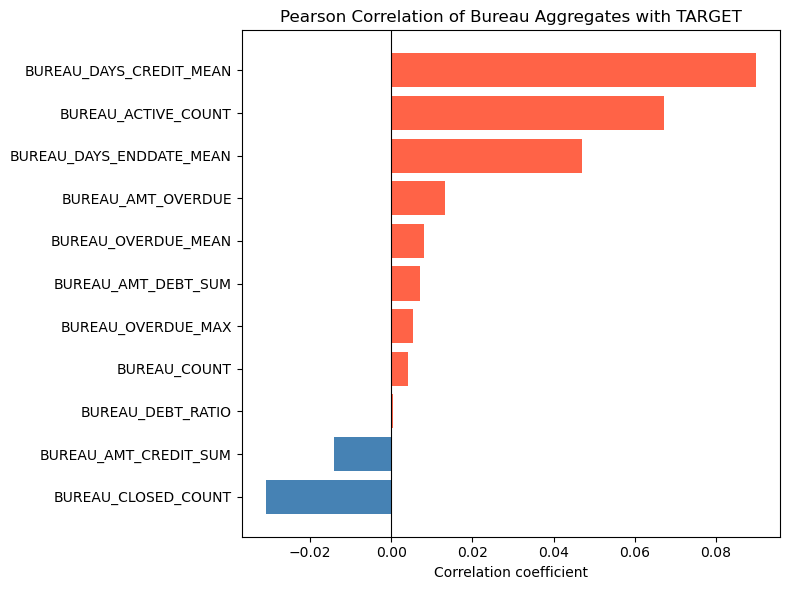

In [22]:
# Correlation of bureau aggregates with TARGET
bureau_num_cols = [c for c in bureau_agg.columns if c != 'SK_ID_CURR']
bureau_corr = (
    train_bureau[bureau_num_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in bureau_corr]
ax.barh(bureau_corr.index, bureau_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Bureau Aggregates with TARGET')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

Default rate – No bureau record: 10.12%
Default rate – Has bureau record: 7.73%


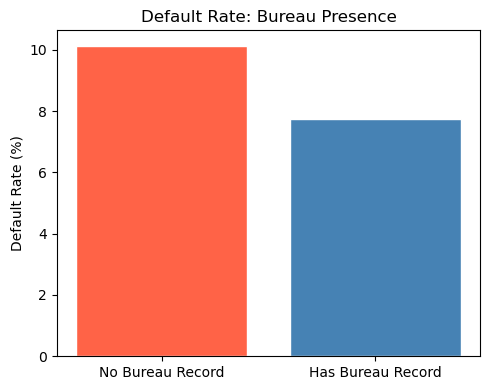

In [23]:
# Default rate: applicants WITH vs WITHOUT bureau records
train_bureau['HAS_BUREAU'] = train_bureau['BUREAU_COUNT'].notna().astype(int)
dr = train_bureau.groupby('HAS_BUREAU')['TARGET'].mean() * 100
print("Default rate – No bureau record: {:.2f}%".format(dr[0]))
print("Default rate – Has bureau record: {:.2f}%".format(dr[1]))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Bureau Record', 'Has Bureau Record'], dr.values, color=['tomato', 'steelblue'], edgecolor='white')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate: Bureau Presence')
plt.tight_layout()
plt.show()

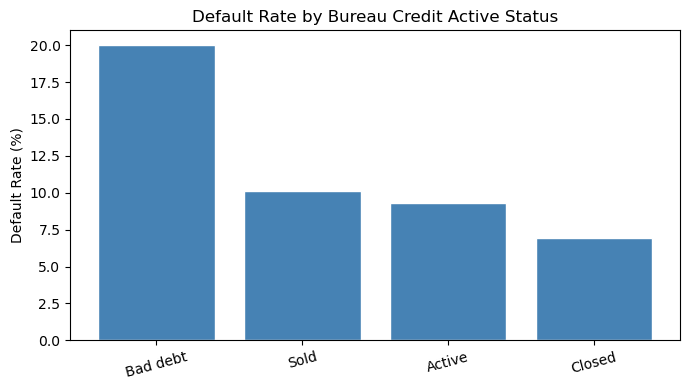

In [24]:
# Default rate by CREDIT_ACTIVE status
bureau_active_train = bureau[['SK_ID_CURR', 'CREDIT_ACTIVE']].merge(
    train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner'
)
dr_active = bureau_active_train.groupby('CREDIT_ACTIVE')['TARGET'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dr_active.index, dr_active.values, color='steelblue', edgecolor='white')
ax.set_title('Default Rate by Bureau Credit Active Status')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

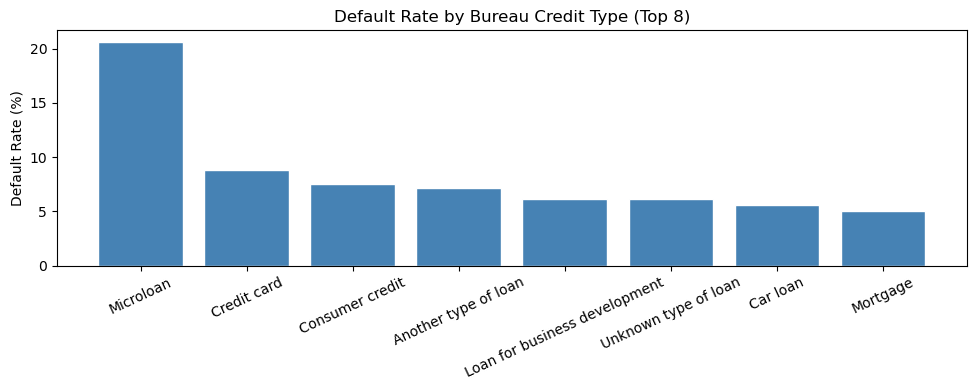

In [25]:
# Default rate by CREDIT_TYPE (top 8 types)
bureau_type_train = bureau[['SK_ID_CURR', 'CREDIT_TYPE']].merge(
    train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner'
)
top_types = bureau['CREDIT_TYPE'].value_counts().nlargest(8).index
dr_type = (
    bureau_type_train[bureau_type_train['CREDIT_TYPE'].isin(top_types)]
    .groupby('CREDIT_TYPE')['TARGET'].mean()
    .sort_values(ascending=False) * 100
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dr_type.index, dr_type.values, color='steelblue', edgecolor='white')
ax.set_title('Default Rate by Bureau Credit Type (Top 8)')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

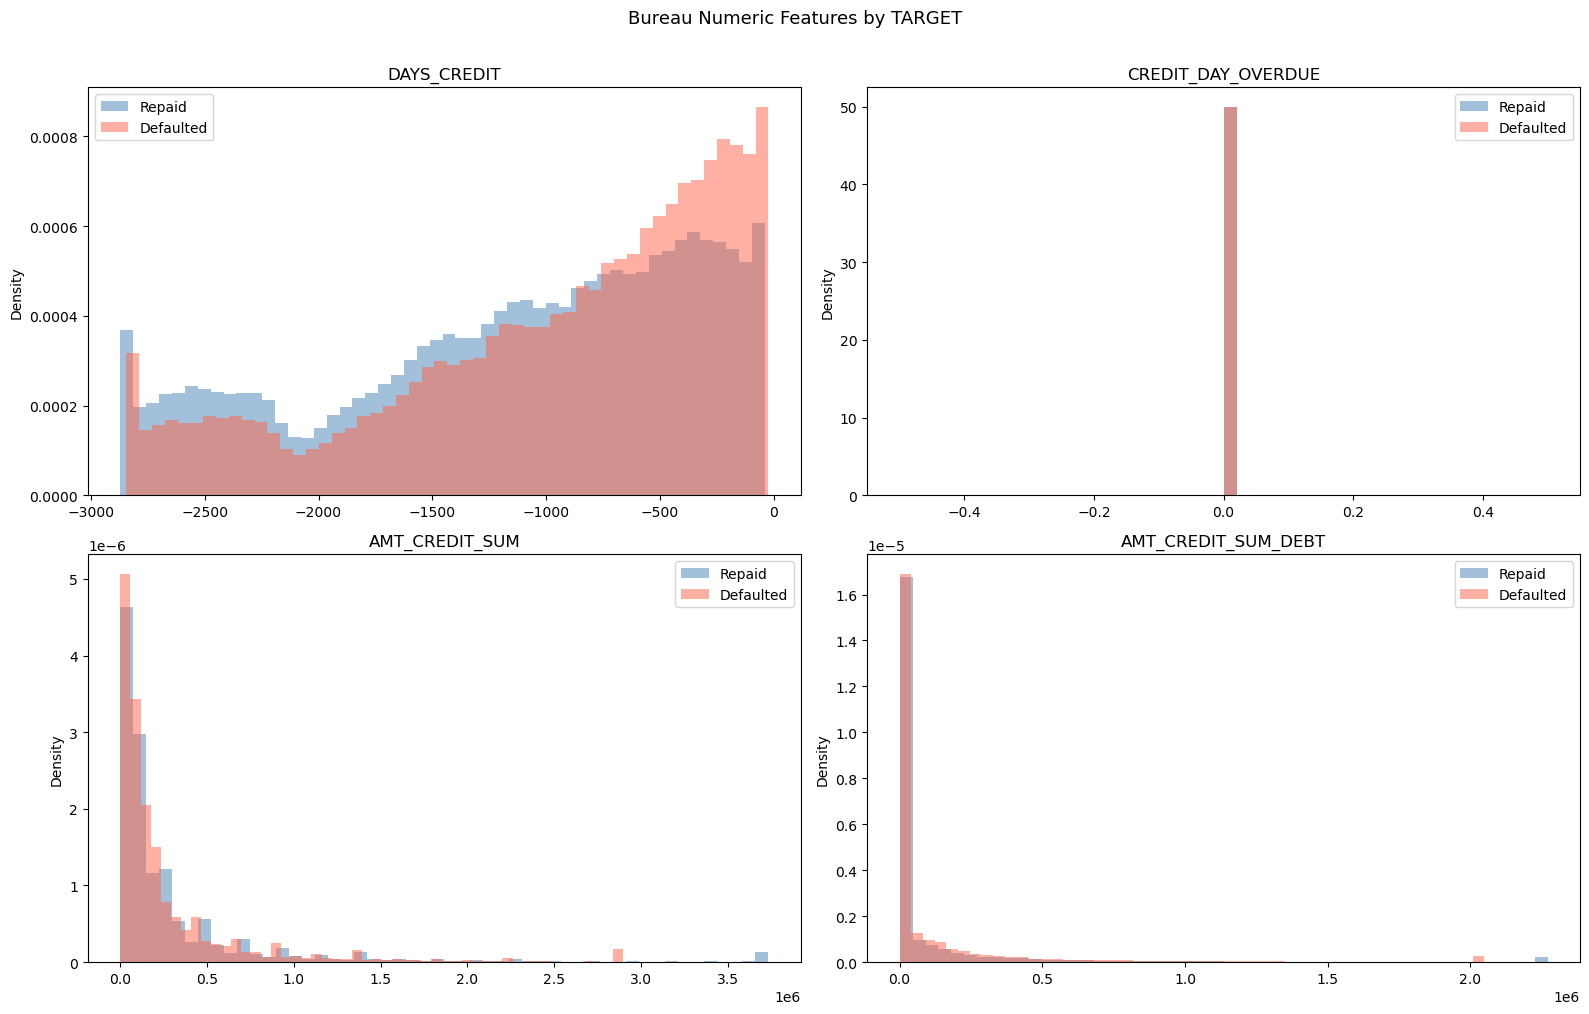

In [26]:
# Distribution of key bureau numeric features by TARGET
bureau_train_full = bureau.merge(train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')

plot_cols = ['DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    for target_val, color, label in [(0, 'steelblue', 'Repaid'), (1, 'tomato', 'Defaulted')]:
        data = bureau_train_full.loc[bureau_train_full['TARGET'] == target_val, col].dropna()
        # Clip extreme outliers for readability
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        data = data.clip(p1, p99)
        axes[i].hist(data, bins=50, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend()
    axes[i].set_ylabel('Density')

plt.suptitle('Bureau Numeric Features by TARGET', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

STATUS value counts:
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64


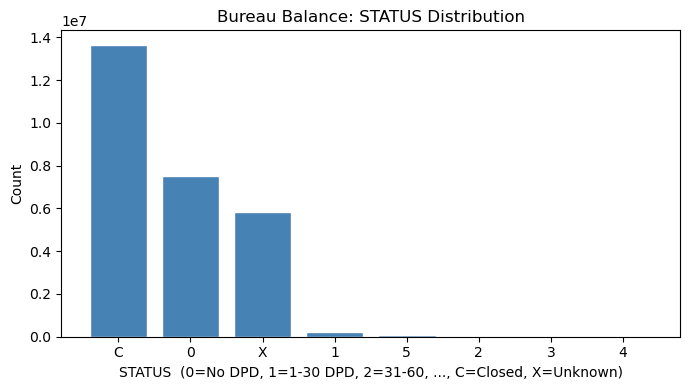

In [27]:
# Bureau balance STATUS distribution
print("STATUS value counts:")
print(bureau_bal['STATUS'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
status_counts = bureau_bal['STATUS'].value_counts()
ax.bar(status_counts.index, status_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Bureau Balance: STATUS Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('STATUS  (0=No DPD, 1=1-30 DPD, 2=31-60, ..., C=Closed, X=Unknown)')
plt.tight_layout()
plt.show()

In [28]:
# Aggregate bureau_balance to bureau level, then up to applicant level
# Encode DPD: treat numeric statuses as overdue counts; C/X = 0
def dpd_flag(s):
    return 1 if s not in ('C', 'X', '0') else 0

bureau_bal['DPD_FLAG'] = bureau_bal['STATUS'].apply(dpd_flag)

bbal_agg = bureau_bal.groupby('SK_ID_BUREAU').agg(
    MONTHS_BALANCE_COUNT = ('MONTHS_BALANCE', 'count'),
    DPD_MONTHS_COUNT     = ('DPD_FLAG', 'sum'),
    DPD_RATIO            = ('DPD_FLAG', 'mean'),
).reset_index()

# Link bureau_bal → bureau → train via SK_ID_BUREAU → SK_ID_CURR
bureau_with_bbal = bureau[['SK_ID_CURR', 'SK_ID_BUREAU']].merge(bbal_agg, on='SK_ID_BUREAU', how='left')

bbal_curr_agg = bureau_with_bbal.groupby('SK_ID_CURR').agg(
    BBAL_MONTHS_TOTAL     = ('MONTHS_BALANCE_COUNT', 'sum'),
    BBAL_DPD_MONTHS_TOTAL = ('DPD_MONTHS_COUNT', 'sum'),
    BBAL_DPD_RATIO_MEAN   = ('DPD_RATIO', 'mean'),
    BBAL_DPD_RATIO_MAX    = ('DPD_RATIO', 'max'),
).reset_index()

train_bbal = train[['SK_ID_CURR', 'TARGET']].merge(bbal_curr_agg, on='SK_ID_CURR', how='left')
print("train_bbal shape:", train_bbal.shape)

train_bbal shape: (307511, 6)


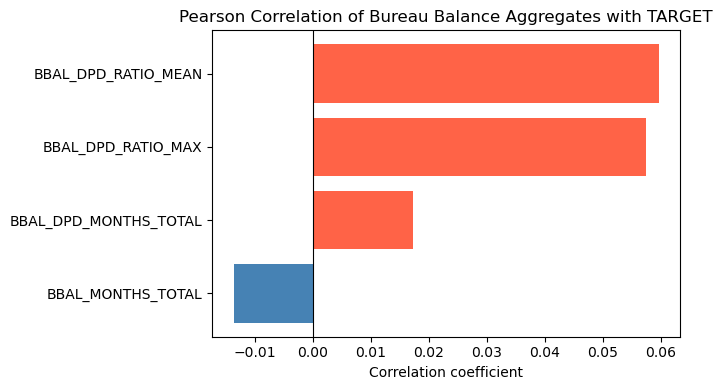

In [29]:
# Correlation of bureau_balance aggregates with TARGET
bbal_feat_cols = [c for c in bbal_curr_agg.columns if c != 'SK_ID_CURR']
bbal_corr = (
    train_bbal[bbal_feat_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if v > 0 else 'steelblue' for v in bbal_corr]
ax.barh(bbal_corr.index, bbal_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Bureau Balance Aggregates with TARGET')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

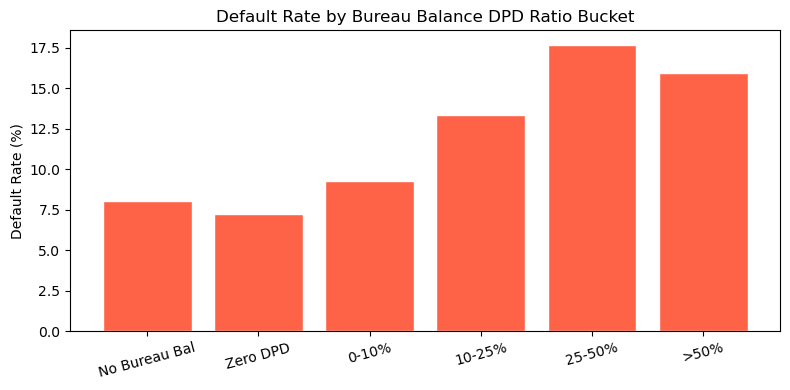

In [30]:
# Default rate by DPD ratio bucket
train_bbal['DPD_RATIO_BIN'] = pd.cut(
    train_bbal['BBAL_DPD_RATIO_MEAN'].fillna(-1),
    bins=[-2, -0.01, 0, 0.1, 0.25, 0.5, 1.01],
    labels=['No Bureau Bal', 'Zero DPD', '0-10%', '10-25%', '25-50%', '>50%']
)

dr_dpd = train_bbal.groupby('DPD_RATIO_BIN')['TARGET'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dr_dpd.index.astype(str), dr_dpd.values, color='tomato', edgecolor='white')
ax.set_title('Default Rate by Bureau Balance DPD Ratio Bucket')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### Key Findings – Bureau & Bureau Balance

| Finding | Detail |
|---|---|
| **Bureau coverage** | Not every applicant has a bureau record; applicants *without* bureau history tend to show a different default profile. |
| **Credit Active status** | Active/Sold credits show higher default rates than closed ones. Bad debt has the highest default rate. |
| **Credit Type** | Consumer credit and credit cards dominate; default rates vary meaningfully across types. |
| **DAYS_CREDIT** | Defaulters tend to have more recent bureau inquiries. |
| **Overdue amount** | `AMT_CREDIT_SUM_OVERDUE` and `CREDIT_DAY_OVERDUE` positively correlate with default. |
| **Bureau Balance DPD** | Higher proportion of delinquent months (DPD_RATIO) is the strongest bureau_balance signal for default. |


## 3.3 Previous Applications

In [31]:
prev_app = load_data('data/previous_application.csv')

print("previous_application shape:", prev_app.shape)
print()
print("Unique SK_ID_CURR:", prev_app['SK_ID_CURR'].nunique())
print("Unique SK_ID_PREV:", prev_app['SK_ID_PREV'].nunique())

previous_application shape: (1670214, 37)

Unique SK_ID_CURR: 338857
Unique SK_ID_PREV: 1670214


In [32]:
prev_missing = missing_summary(prev_app, "previous_application")
display(prev_missing.head(15))


previous_application: 16 columns have missing values


,missing_count,missing_pct
RATE_INTEREST_PRIVILEGED,1664263,99.64
RATE_INTEREST_PRIMARY,1664263,99.64
AMT_DOWN_PAYMENT,895844,53.64
RATE_DOWN_PAYMENT,895844,53.64
NAME_TYPE_SUITE,820405,49.12
DAYS_LAST_DUE,673065,40.30
DAYS_FIRST_DRAWING,673065,40.30
DAYS_FIRST_DUE,673065,40.30
DAYS_TERMINATION,673065,40.30
NFLAG_INSURED_ON_APPROVAL,673065,40.30


In [33]:
apps_per_applicant = prev_app.groupby('SK_ID_CURR').size()
print("Previous applications per applicant:")
print(apps_per_applicant.describe().round(2))

Previous applications per applicant:
count    338857.00
mean          4.93
std           4.22
min           1.00
25%           2.00
50%           4.00
75%           7.00
max          77.00
dtype: float64


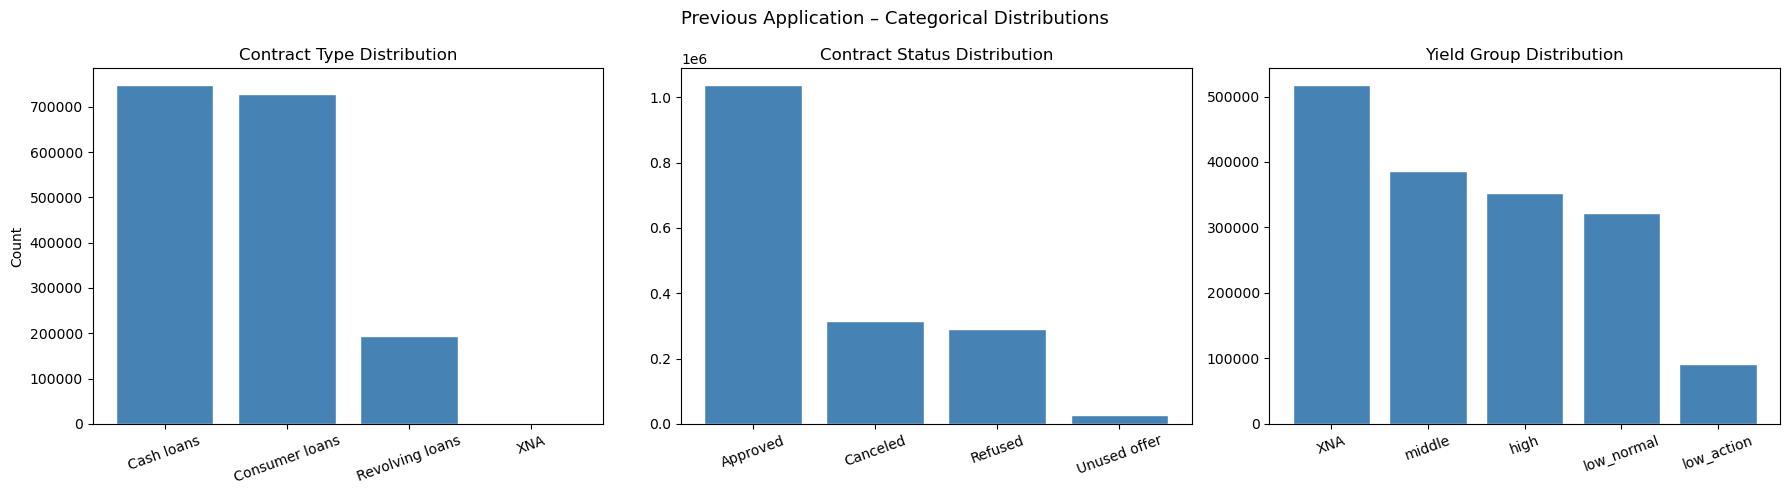

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Contract type 
ct = prev_app["NAME_CONTRACT_TYPE"].value_counts()
axes[0].bar(ct.index, ct.values, color='steelblue', edgecolor='white')
axes[0].set_title('Contract Type Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Contract status 
cs = prev_app['NAME_CONTRACT_STATUS'].value_counts()
axes[1].bar(cs.index, cs.values, color='steelblue', edgecolor='white')
axes[1].set_title('Contract Status Distribution')
axes[1].tick_params(axis='x', rotation=20)

# Yield group (risk tier)
yg = prev_app['NAME_YIELD_GROUP'].value_counts()
axes[2].bar(yg.index, yg.values, color='steelblue', edgecolor='white')
axes[2].set_title('Yield Group Distribution')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Previous Application – Categorical Distributions', fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
# Aggregate previous_application features per applicant
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_COUNT              = ('SK_ID_PREV', 'count'),
    PREV_APPROVED_COUNT     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT      = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    PREV_CANCELED_COUNT     = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Canceled').sum()),
    PREV_AMT_CREDIT_MEAN    = ('AMT_CREDIT', 'mean'),
    PREV_AMT_CREDIT_MAX     = ('AMT_CREDIT', 'max'),
    PREV_AMT_APPLICATION_MEAN = ('AMT_APPLICATION', 'mean'),
    PREV_AMT_DOWN_PAYMENT_MEAN = ('AMT_DOWN_PAYMENT', 'mean'),
    PREV_RATE_INTEREST_PRIMARY_MEAN = ('RATE_INTEREST_PRIMARY', 'mean'),
    PREV_DAYS_DECISION_MEAN = ('DAYS_DECISION', 'mean'),
    PREV_DAYS_LAST_DUE_MEAN = ('DAYS_LAST_DUE', 'mean'),
    PREV_CNT_PAYMENT_MEAN   = ('CNT_PAYMENT', 'mean'),
).reset_index()

prev_agg['PREV_APPROVAL_RATE'] = (
    prev_agg['PREV_APPROVED_COUNT'] / prev_agg['PREV_COUNT']
)
prev_agg['PREV_REFUSAL_RATE'] = (
    prev_agg['PREV_REFUSED_COUNT'] / prev_agg['PREV_COUNT']
)
prev_agg['PREV_CREDIT_APP_RATIO'] = (
    prev_agg['PREV_AMT_CREDIT_MEAN'] / (prev_agg['PREV_AMT_APPLICATION_MEAN'] + 1)
)

train_prev = train[['SK_ID_CURR', 'TARGET']].merge(prev_agg, on='SK_ID_CURR', how='left')
print("train_prev shape:", train_prev.shape)
print("Applicants with NO previous application:", train_prev['PREV_COUNT'].isnull().sum())

train_prev shape: (307511, 17)
Applicants with NO previous application: 16454


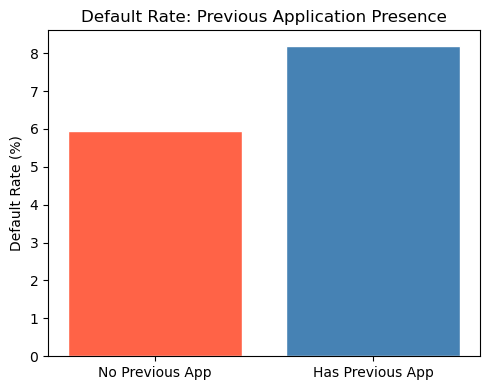

In [36]:
train_prev['HAS_PREV'] = train_prev['PREV_COUNT'].notna().astype(int)
dr_prev = train_prev.groupby('HAS_PREV')['TARGET'].mean() * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Previous App', 'Has Previous App'], dr_prev.values, color=['tomato', 'steelblue'], edgecolor='white')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate: Previous Application Presence')
plt.tight_layout()
plt.show()

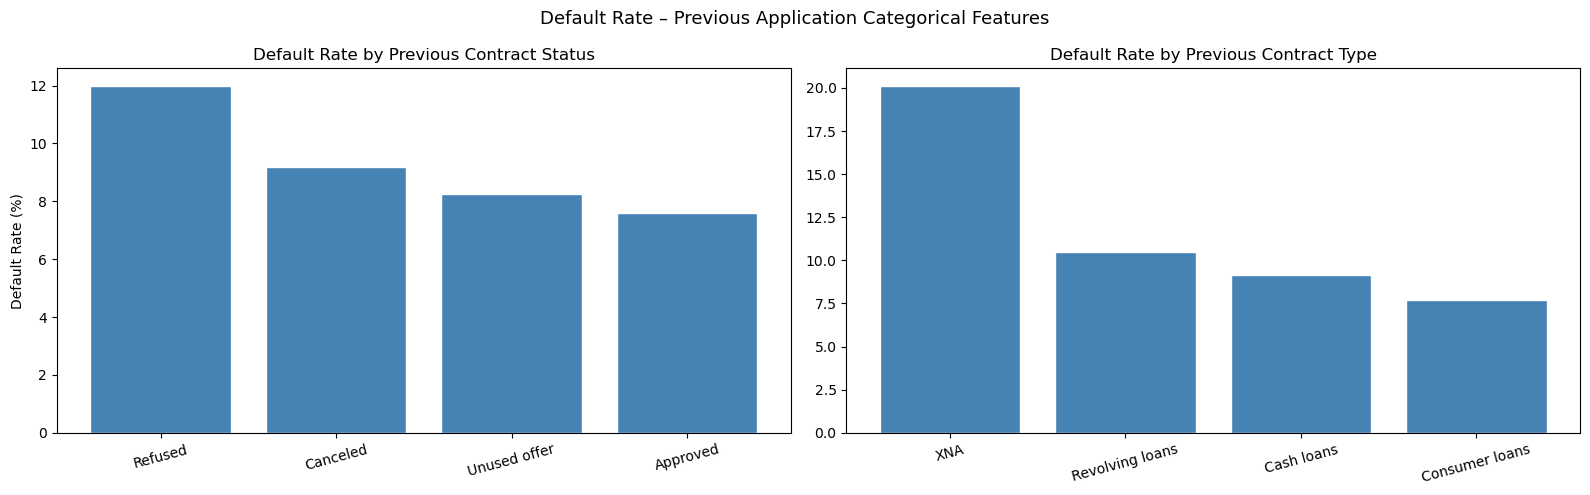

In [37]:
prev_train_full = prev_app.merge(train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By contract status
dr_status = (prev_train_full.groupby('NAME_CONTRACT_STATUS')['TARGET']
             .mean().sort_values(ascending=False) * 100)
axes[0].bar(dr_status.index, dr_status.values, color='steelblue', edgecolor='white')
axes[0].set_title('Default Rate by Previous Contract Status')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

# By contract type
dr_ct = (prev_train_full.groupby('NAME_CONTRACT_TYPE')['TARGET']
         .mean().sort_values(ascending=False) * 100)
axes[1].bar(dr_ct.index, dr_ct.values, color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Previous Contract Type')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Default Rate – Previous Application Categorical Features', fontsize=13)
plt.tight_layout()
plt.show()

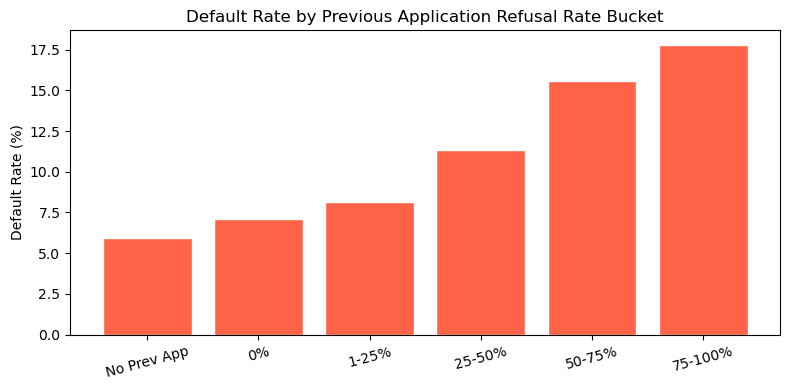

In [38]:
train_prev['REFUSAL_RATE_BIN'] = pd.cut(
    train_prev['PREV_REFUSAL_RATE'].fillna(-1),
    bins=[-2, -0.01, 0, 0.25, 0.5, 0.75, 1.01],
    labels=['No Prev App', '0%', '1-25%', '25-50%', '50-75%', '75-100%']
)

dr_refusal = train_prev.groupby('REFUSAL_RATE_BIN')['TARGET'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dr_refusal.index.astype(str), dr_refusal.values, color='tomato', edgecolor='white')
ax.set_title('Default Rate by Previous Application Refusal Rate Bucket')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

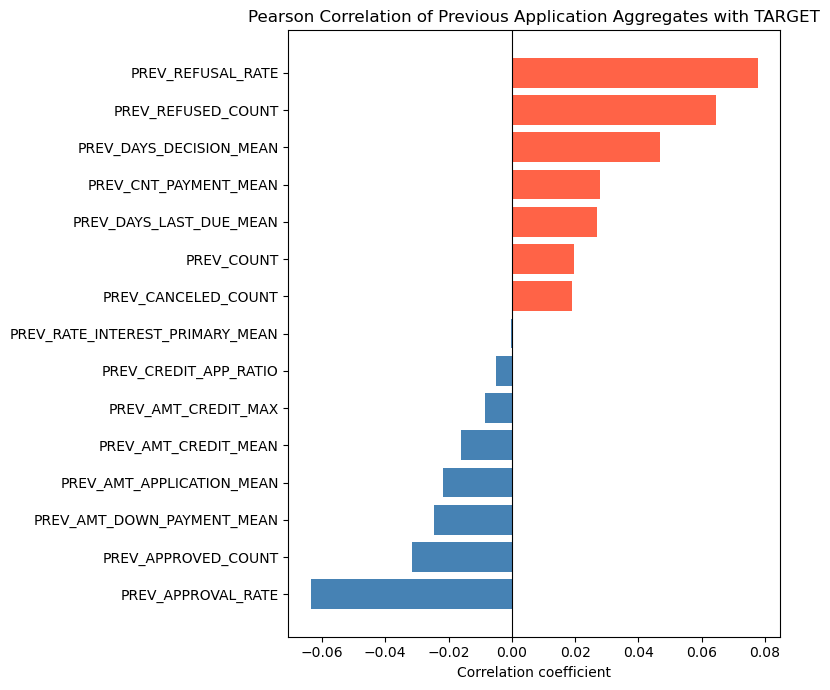

In [39]:
prev_feat_cols = [c for c in prev_agg.columns if c != 'SK_ID_CURR']
prev_corr = (
    train_prev[prev_feat_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['tomato' if v > 0 else 'steelblue' for v in prev_corr]
ax.barh(prev_corr.index, prev_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Previous Application Aggregates with TARGET')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

### Key Findings – Previous Applications

| Finding | Detail |
|---|---|
| **Prior refusals** | Higher refusal rate in previous applications is associated with a higher current default rate. |
| **Contract status** | Approved previous contracts have the lowest default rate; unused/canceled contracts are higher risk. |
| **Days decision** | Recency of the last previous application (DAYS_DECISION) correlates with current default risk. |
| **No previous applications** | Applicants with no prior Home Credit history have a distinct, slightly elevated default profile. |


## 3.4. POS Cash Balance

In [40]:
pos = load_data('data/POS_CASH_balance.csv')

print("POS_CASH_balance shape:", pos.shape)
print()
print("Unique SK_ID_CURR:", pos['SK_ID_CURR'].nunique())
print("Unique SK_ID_PREV:", pos['SK_ID_PREV'].nunique())

POS_CASH_balance shape: (10001358, 8)

Unique SK_ID_CURR: 337252
Unique SK_ID_PREV: 936325


In [41]:
pos_missing = missing_summary(pos, "POS_CASH_balance")
display(pos_missing)


POS_CASH_balance: 2 columns have missing values


,missing_count,missing_pct
CNT_INSTALMENT,26071,0.26
CNT_INSTALMENT_FUTURE,26087,0.26


NAME_CONTRACT_STATUS value counts:
NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64


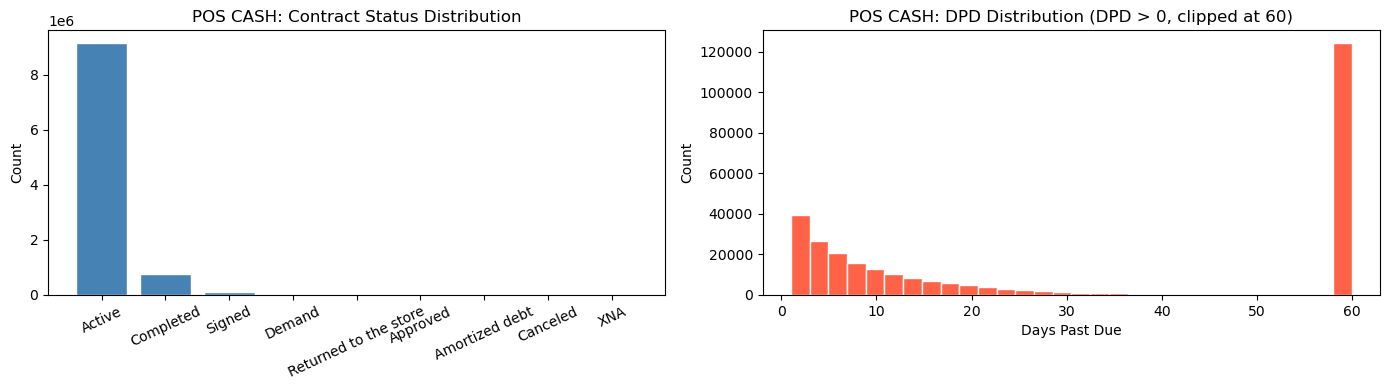

In [42]:
print("NAME_CONTRACT_STATUS value counts:")
print(pos['NAME_CONTRACT_STATUS'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

status_counts = pos['NAME_CONTRACT_STATUS'].value_counts()
axes[0].bar(status_counts.index, status_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('POS CASH: Contract Status Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)

# DPD distribution (clip for readability)
dpd_data = pos['SK_DPD'].clip(0, 60).dropna()
axes[1].hist(dpd_data[dpd_data > 0], bins=30, color='tomato', edgecolor='white')
axes[1].set_title('POS CASH: DPD Distribution (DPD > 0, clipped at 60)')
axes[1].set_xlabel('Days Past Due')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [43]:
# Aggregate POS CASH at SK_ID_CURR level
pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_COUNT                 = ('SK_ID_PREV', 'count'),
    POS_MONTHS_COUNT          = ('MONTHS_BALANCE', 'count'),
    POS_SK_DPD_MAX            = ('SK_DPD', 'max'),
    POS_SK_DPD_MEAN           = ('SK_DPD', 'mean'),
    POS_SK_DPD_DEF_MAX        = ('SK_DPD_DEF', 'max'),
    POS_SK_DPD_DEF_MEAN       = ('SK_DPD_DEF', 'mean'),
    POS_CNT_INSTALMENT_MEAN   = ('CNT_INSTALMENT', 'mean'),
    POS_COMPLETED_COUNT       = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Completed').sum()),
    POS_ACTIVE_COUNT          = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Active').sum()),
).reset_index()

pos_agg['POS_DPD_RATIO'] = (pos_agg['POS_SK_DPD_MEAN'] > 0).astype(int)
pos_agg['POS_COMPLETED_RATIO'] = pos_agg['POS_COMPLETED_COUNT'] / pos_agg['POS_COUNT']

train_pos = train[['SK_ID_CURR', 'TARGET']].merge(pos_agg, on='SK_ID_CURR', how='left')
print("train_pos shape:", train_pos.shape)

train_pos shape: (307511, 13)


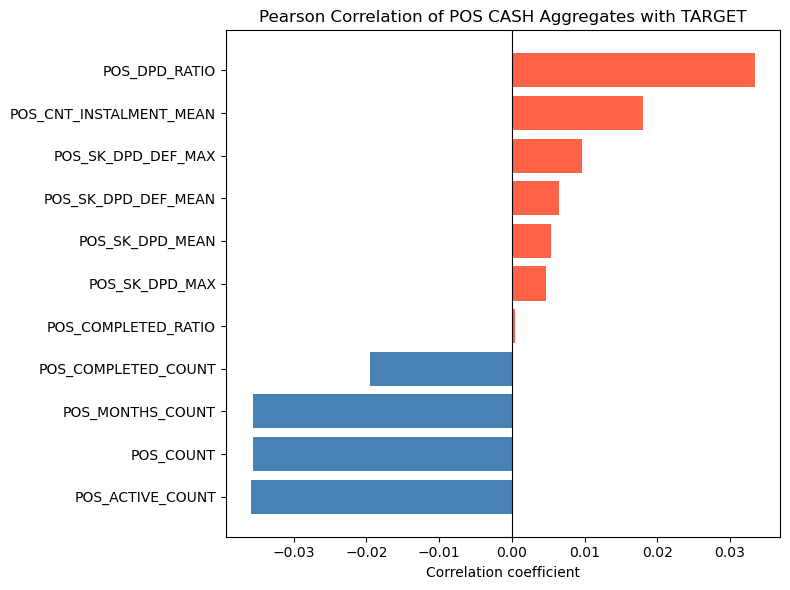

In [44]:
# Correlation of POS aggregates with TARGET
pos_feat_cols = [c for c in pos_agg.columns if c != 'SK_ID_CURR']
pos_corr = (
    train_pos[pos_feat_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in pos_corr]
ax.barh(pos_corr.index, pos_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of POS CASH Aggregates with TARGET')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

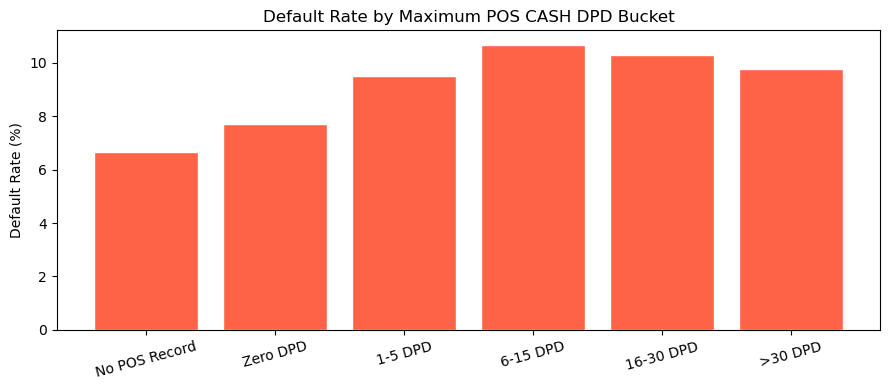

In [45]:
# Default rate by DPD bucket (POS)
train_pos['POS_DPD_BIN'] = pd.cut(
    train_pos['POS_SK_DPD_MAX'].fillna(-1),
    bins=[-2, -0.01, 0, 5, 15, 30, 500],
    labels=['No POS Record', 'Zero DPD', '1-5 DPD', '6-15 DPD', '16-30 DPD', '>30 DPD']
)

dr_pos = train_pos.groupby('POS_DPD_BIN')['TARGET'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dr_pos.index.astype(str), dr_pos.values, color='tomato', edgecolor='white')
ax.set_title('Default Rate by Maximum POS CASH DPD Bucket')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### Key Findings – POS CASH Balance

| Finding | Detail |
|---|---|
| **DPD signal** | `SK_DPD_MAX` and `SK_DPD_DEF_MAX` are the strongest POS signals — even a single delinquent POS month raises default probability. |
| **Completed contracts** | Higher proportion of completed (vs active) POS contracts correlates with lower default risk. |
| **Active contracts** | Applicants with many currently active POS contracts show elevated default rates. |

## 3.5 Installments Payments and Credit Card Balance

In [46]:
inst = load_data('data/installments_payments.csv')
cc   = load_data('data/credit_card_balance.csv')
prev = load_data('data/previous_application.csv')[['SK_ID_PREV', 'SK_ID_CURR']]  # bridge table

print("installments_payments shape:", inst.shape)
print("credit_card_balance shape  :", cc.shape)

installments_payments shape: (13605401, 8)
credit_card_balance shape  : (3840312, 23)


In [47]:
inst_missing = missing_summary(inst, "installments_payments")
display(inst_missing)

cc_missing = missing_summary(cc, "credit_card_balance")
display(cc_missing)


installments_payments: 2 columns have missing values


,missing_count,missing_pct
DAYS_ENTRY_PAYMENT,2905,0.02
AMT_PAYMENT,2905,0.02



credit_card_balance: 9 columns have missing values


,missing_count,missing_pct
AMT_PAYMENT_CURRENT,767988,20.00
AMT_DRAWINGS_ATM_CURRENT,749816,19.52
AMT_DRAWINGS_OTHER_CURRENT,749816,19.52
AMT_DRAWINGS_POS_CURRENT,749816,19.52
CNT_DRAWINGS_ATM_CURRENT,749816,19.52
CNT_DRAWINGS_POS_CURRENT,749816,19.52
CNT_DRAWINGS_OTHER_CURRENT,749816,19.52
AMT_INST_MIN_REGULARITY,305236,7.95
CNT_INSTALMENT_MATURE_CUM,305236,7.95


In [48]:
inst['payment_diff'] = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']   # > 0 → underpaid
inst['days_late']    = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']  # > 0 → paid late

inst.describe()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,payment_diff,days_late
count,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360250e+07,1.360540e+07,1.360250e+07,1.360250e+07,1.360250e+07
mean,1.903365e+06,2.784449e+05,8.566373e-01,1.887090e+01,-1.042270e+03,-1.051114e+03,1.705091e+04,1.723822e+04,-1.871538e+02,-8.787405e+00
std,5.362029e+05,1.027183e+05,1.035216e+00,2.666407e+01,8.009463e+02,8.005859e+02,5.057025e+04,5.473578e+04,1.910673e+04,2.553990e+01
min,1.000001e+06,1.000010e+05,0.000000e+00,1.000000e+00,-2.922000e+03,-4.921000e+03,0.000000e+00,0.000000e+00,-2.630909e+06,-3.189000e+03
25%,1.434191e+06,1.896390e+05,0.000000e+00,4.000000e+00,-1.654000e+03,-1.662000e+03,4.226085e+03,3.398265e+03,0.000000e+00,-1.400000e+01
50%,1.896520e+06,2.786850e+05,1.000000e+00,8.000000e+00,-8.180000e+02,-8.270000e+02,8.884080e+03,8.125515e+03,0.000000e+00,-6.000000e+00
75%,2.369094e+06,3.675300e+05,1.000000e+00,1.900000e+01,-3.610000e+02,-3.700000e+02,1.671021e+04,1.610842e+04,0.000000e+00,0.000000e+00
max,2.843499e+06,4.562550e+05,1.780000e+02,2.770000e+02,-1.000000e+00,-1.000000e+00,3.771488e+06,3.771488e+06,2.424726e+06,2.884000e+03


In [ ]:
# Aggregate to applicant level 
inst_agg = (
    inst.groupby('SK_ID_PREV')
    .agg(
        n_instalments        = ('NUM_INSTALMENT_NUMBER', 'max'),
        mean_payment_diff    = ('payment_diff',          'mean'),
        max_payment_diff     = ('payment_diff',          'max'),   # worst single shortfall
        pct_late             = ('days_late',             lambda x: (x > 0).mean()),
        mean_days_late       = ('days_late',             lambda x: x[x > 0].mean()),
    )
    .reset_index()
)

# Roll up from SK_ID_PREV → SK_ID_CURR
inst_curr = (
    inst_agg
    .merge(prev, on='SK_ID_PREV', how='left')
    .groupby('SK_ID_CURR')
    .agg(
        inst_n_instalments        = ('n_instalments',     'sum'),
        inst_mean_payment_diff    = ('mean_payment_diff', 'mean'),
        inst_max_payment_diff     = ('max_payment_diff',  'max'),
        inst_pct_late             = ('pct_late',          'mean'),
        inst_mean_days_late       = ('mean_days_late',    'mean'),
    )
    .reset_index()
)

# Attach target
inst_df = inst_curr.merge(train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')
print(inst_df.shape)
inst_df.describe()

(289406, 7)


,SK_ID_CURR,inst_n_instalments,inst_mean_payment_diff,inst_max_payment_diff,inst_pct_late,inst_mean_days_late,TARGET
count,289406.000000,289406.000000,289398.000000,2.893980e+05,289406.000000,150169.000000,289406.000000
mean,278225.672588,37.281877,-537.927761,6.699240e+03,0.067098,12.397584,0.081892
std,102836.729679,38.985799,5915.232218,1.523359e+04,0.106304,61.743488,0.274200
min,100002.000000,1.000000,-409002.771094,-3.899106e+04,0.000000,1.000000,0.000000
25%,189157.250000,12.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000
50%,278332.500000,23.000000,0.000000,0.000000e+00,0.011111,4.023810,0.000000
75%,367286.750000,47.000000,393.111012,9.045000e+03,0.100000,8.555556,0.000000
max,456255.000000,563.000000,146145.900000,2.424726e+06,1.000000,2444.000000,1.000000


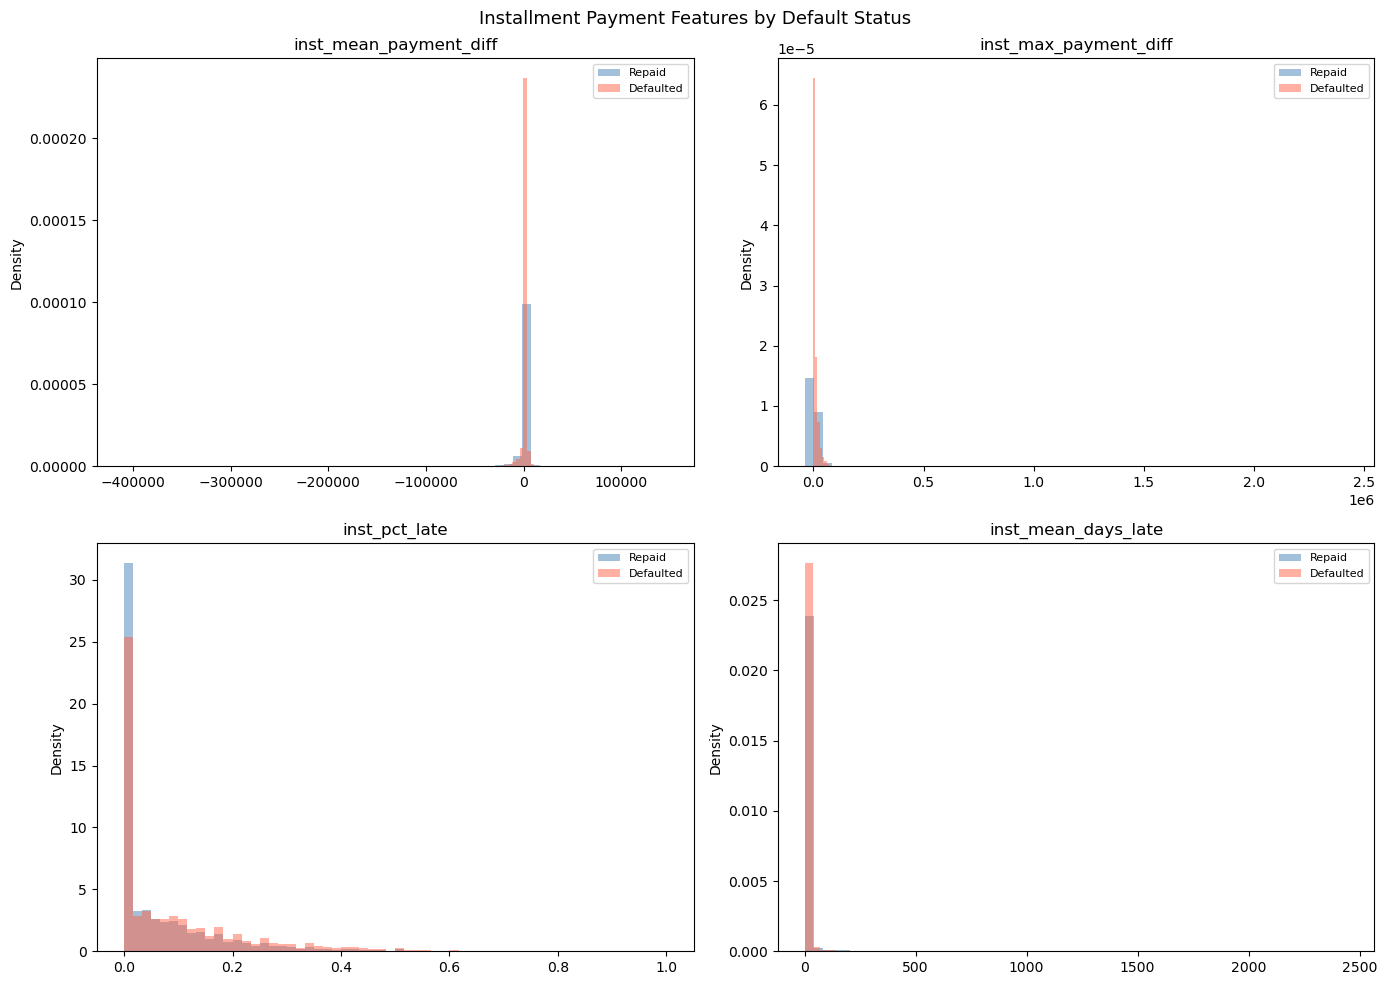

In [ ]:
# Distribution of payment features by default 
inst_plot_cols = [
    'inst_mean_payment_diff', 'inst_max_payment_diff',
    'inst_pct_late',          'inst_mean_days_late'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(inst_plot_cols):
    for tval, color, label in [(0, 'steelblue', 'Repaid'), (1, 'tomato', 'Defaulted')]:
        data = inst_df.loc[inst_df['TARGET'] == tval, col].dropna()
        axes[i].hist(data, bins=60, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Installment Payment Features by Default Status', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Checking outliers 
display(iqr_outlier_summary(inst_df, inst_plot_cols))

,Q1,Q3,IQR,n_outliers,outlier_pct
feature,,,,,
inst_mean_payment_diff,0.0,393.111012,393.111012,71704,24.78
inst_max_payment_diff,0.0,9045.000000,9045.000000,25732,8.89
inst_mean_days_late,2.0,8.555556,6.555556,12331,8.21
inst_pct_late,0.0,0.100000,0.100000,19196,6.63


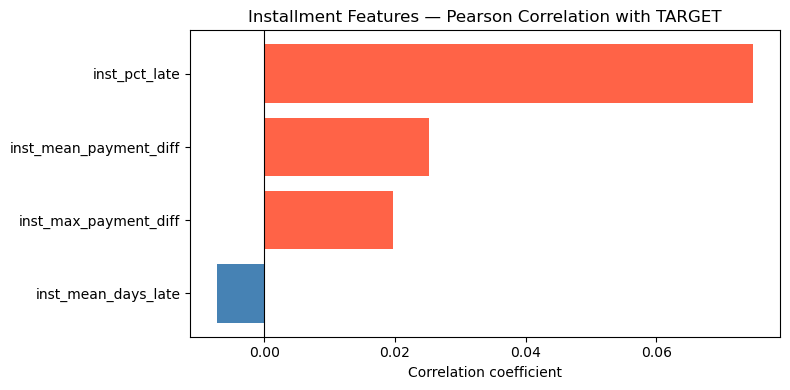

In [ ]:
# Correlation of installments_payments features with target variable 
inst_corr = (
    inst_df[inst_plot_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if v > 0 else 'steelblue' for v in inst_corr]
ax.barh(inst_corr.index, inst_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Installment Features — Pearson Correlation with TARGET')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

In [54]:
cc['utilisation'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
cc['payment_ratio'] = cc['AMT_PAYMENT_CURRENT'] / cc['AMT_INST_MIN_REGULARITY'].replace(0, np.nan)

cc[['AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'utilisation', 'SK_DPD', 'payment_ratio']].describe()

,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,utilisation,SK_DPD,payment_ratio
count,3.840312e+06,3.840312e+06,3.086489e+06,3.840312e+06,1.606003e+06
mean,5.830016e+04,1.538080e+05,3.746669e-01,9.283667e+00,1.026126e+01
std,1.063070e+05,1.651457e+05,4.307236e-01,9.751570e+01,2.614475e+03
min,-4.202502e+05,0.000000e+00,-1.800000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,4.500000e+04,0.000000e+00,0.000000e+00,1.000000e+00
50%,0.000000e+00,1.125000e+05,1.134400e-02,0.000000e+00,1.065772e+00
75%,8.904669e+04,1.800000e+05,8.691224e-01,0.000000e+00,1.995973e+00
max,1.505902e+06,1.350000e+06,1.177751e+01,3.260000e+03,2.975900e+06


In [ ]:
# Aggregate to applicant level 
cc_agg = (
    cc.groupby('SK_ID_PREV')
    .agg(
        cc_mean_balance     = ('AMT_BALANCE',             'mean'),
        cc_max_balance      = ('AMT_BALANCE',             'max'),
        cc_mean_utilisation = ('utilisation',             'mean'),
        cc_max_utilisation  = ('utilisation',             'max'),
        cc_mean_dpd         = ('SK_DPD',                  'mean'),
        cc_max_dpd          = ('SK_DPD',                  'max'),
        cc_pct_dpd          = ('SK_DPD',                  lambda x: (x > 0).mean()),
        cc_mean_payment_ratio = ('payment_ratio',         'mean'),
        cc_total_drawings   = ('AMT_DRAWINGS_CURRENT',    'sum'),
    )
    .reset_index()
)

# Roll up from SK_ID_PREV → SK_ID_CURR
cc_curr = (
    cc_agg
    .merge(prev, on='SK_ID_PREV', how='left')
    .groupby('SK_ID_CURR')
    .agg(
        cc_mean_balance       = ('cc_mean_balance',       'mean'),
        cc_max_balance        = ('cc_max_balance',        'max'),
        cc_mean_utilisation   = ('cc_mean_utilisation',   'mean'),
        cc_max_utilisation    = ('cc_max_utilisation',    'max'),
        cc_mean_dpd           = ('cc_mean_dpd',           'mean'),
        cc_max_dpd            = ('cc_max_dpd',            'max'),
        cc_pct_dpd            = ('cc_pct_dpd',            'mean'),
        cc_mean_payment_ratio = ('cc_mean_payment_ratio', 'mean'),
        cc_total_drawings     = ('cc_total_drawings',     'sum'),
    )
    .reset_index()
)

cc_df = cc_curr.merge(train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')
print(cc_df.shape)
cc_df.describe()

(77934, 11)


,SK_ID_CURR,cc_mean_balance,cc_max_balance,cc_mean_utilisation,cc_max_utilisation,cc_mean_dpd,cc_max_dpd,cc_pct_dpd,cc_mean_payment_ratio,cc_total_drawings,TARGET
count,77934.000000,77934.000000,7.793400e+04,77061.000000,77061.000000,77934.000000,77934.000000,77934.000000,51298.000000,7.793400e+04,77934.000000
mean,278560.949586,75634.628384,1.479438e+05,0.327186,0.606032,3.142326,12.457015,0.017086,20.299342,2.842074e+05,0.090384
std,102718.022276,113612.338217,1.800487e+05,0.332938,0.486380,37.823598,120.274627,0.070830,2195.040274,4.555738e+05,0.286733
min,100006.000000,-2930.232558,0.000000e+00,-0.084848,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,189740.500000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.396953,0.000000e+00,0.000000
50%,278666.500000,28871.851875,9.666477e+04,0.243299,0.923156,0.000000,0.000000,0.000000,2.452858,1.525500e+05,0.000000
75%,367703.750000,106291.295118,2.108229e+05,0.608917,1.043065,0.000000,0.000000,0.000000,5.223722,3.764189e+05,0.000000
max,456248.000000,928686.323571,1.354829e+06,1.564907,11.777510,1342.263158,2770.000000,0.975610,496093.080083,1.846930e+07,1.000000


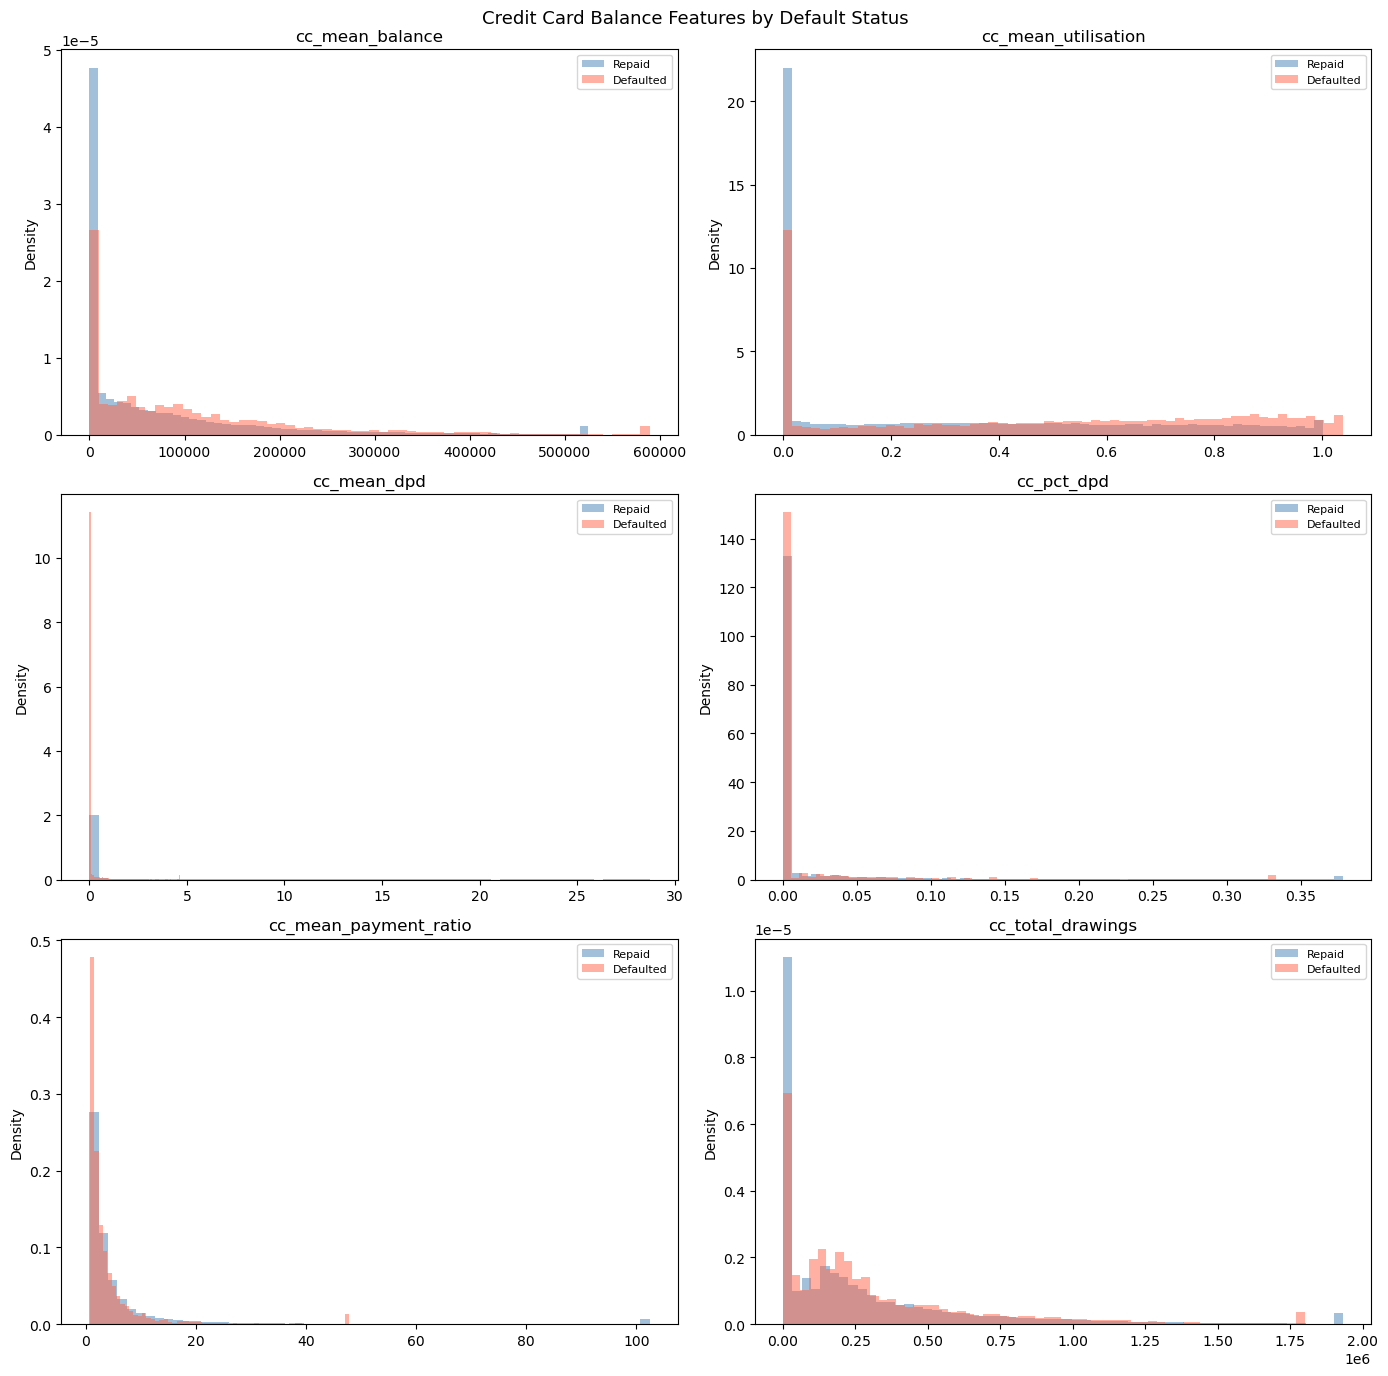

In [ ]:
# Distribution of credit cards features by default 
cc_plot_cols = [
    'cc_mean_balance', 'cc_mean_utilisation',
    'cc_mean_dpd',     'cc_pct_dpd',
    'cc_mean_payment_ratio', 'cc_total_drawings'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cc_plot_cols):
    for tval, color, label in [(0, 'steelblue', 'Repaid'), (1, 'tomato', 'Defaulted')]:
        data = cc_df.loc[cc_df['TARGET'] == tval, col].dropna()
        # clip extreme outliers for readability
        p1, p99 = data.quantile(0.01), data.quantile(0.99)
        data = data.clip(p1, p99)
        axes[i].hist(data, bins=60, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Credit Card Balance Features by Default Status', fontsize=13)
plt.tight_layout()
plt.show()

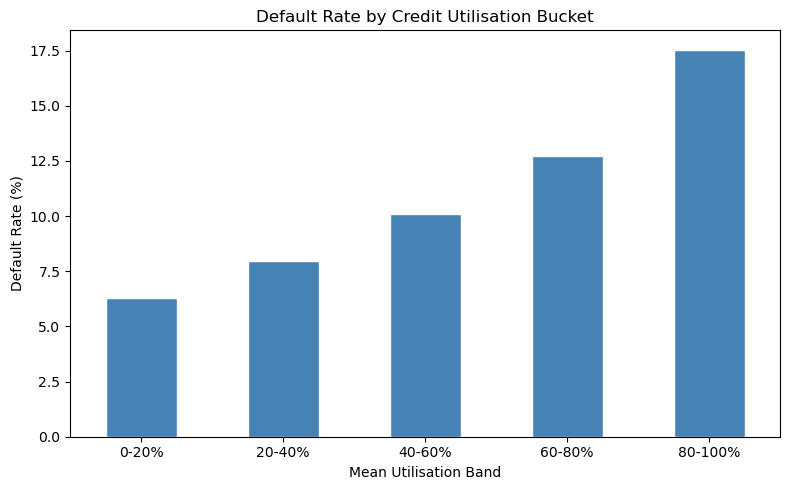

In [ ]:
# Credit card utilisation bucket vs. default rate 
cc_df['util_bin'] = pd.cut(
    cc_df['cc_mean_utilisation'].clip(0, 1),
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)

util_default = cc_df.groupby('util_bin', observed=True)['TARGET'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
util_default.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Default Rate by Credit Utilisation Bucket')
ax.set_xlabel('Mean Utilisation Band')
ax.set_ylabel('Default Rate (%)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

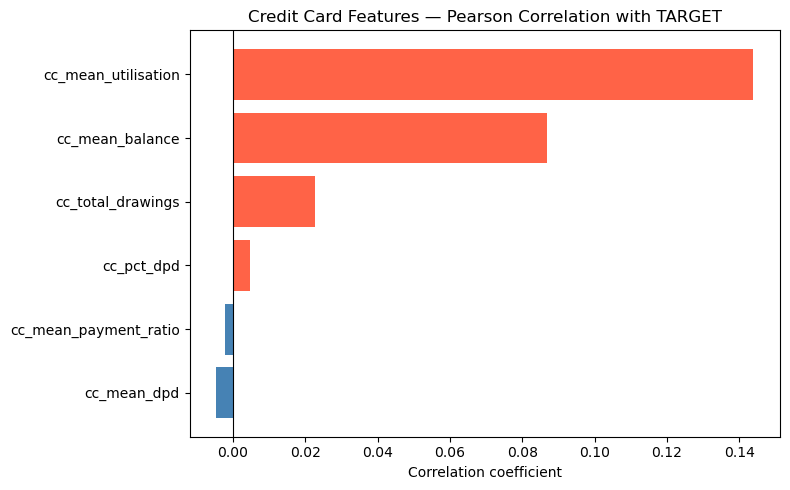

In [ ]:
# Correlation of credit card features with target 
cc_corr = (
    cc_df[cc_plot_cols + ['TARGET']]
    .corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in cc_corr]
ax.barh(cc_corr.index, cc_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Credit Card Features — Pearson Correlation with TARGET')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

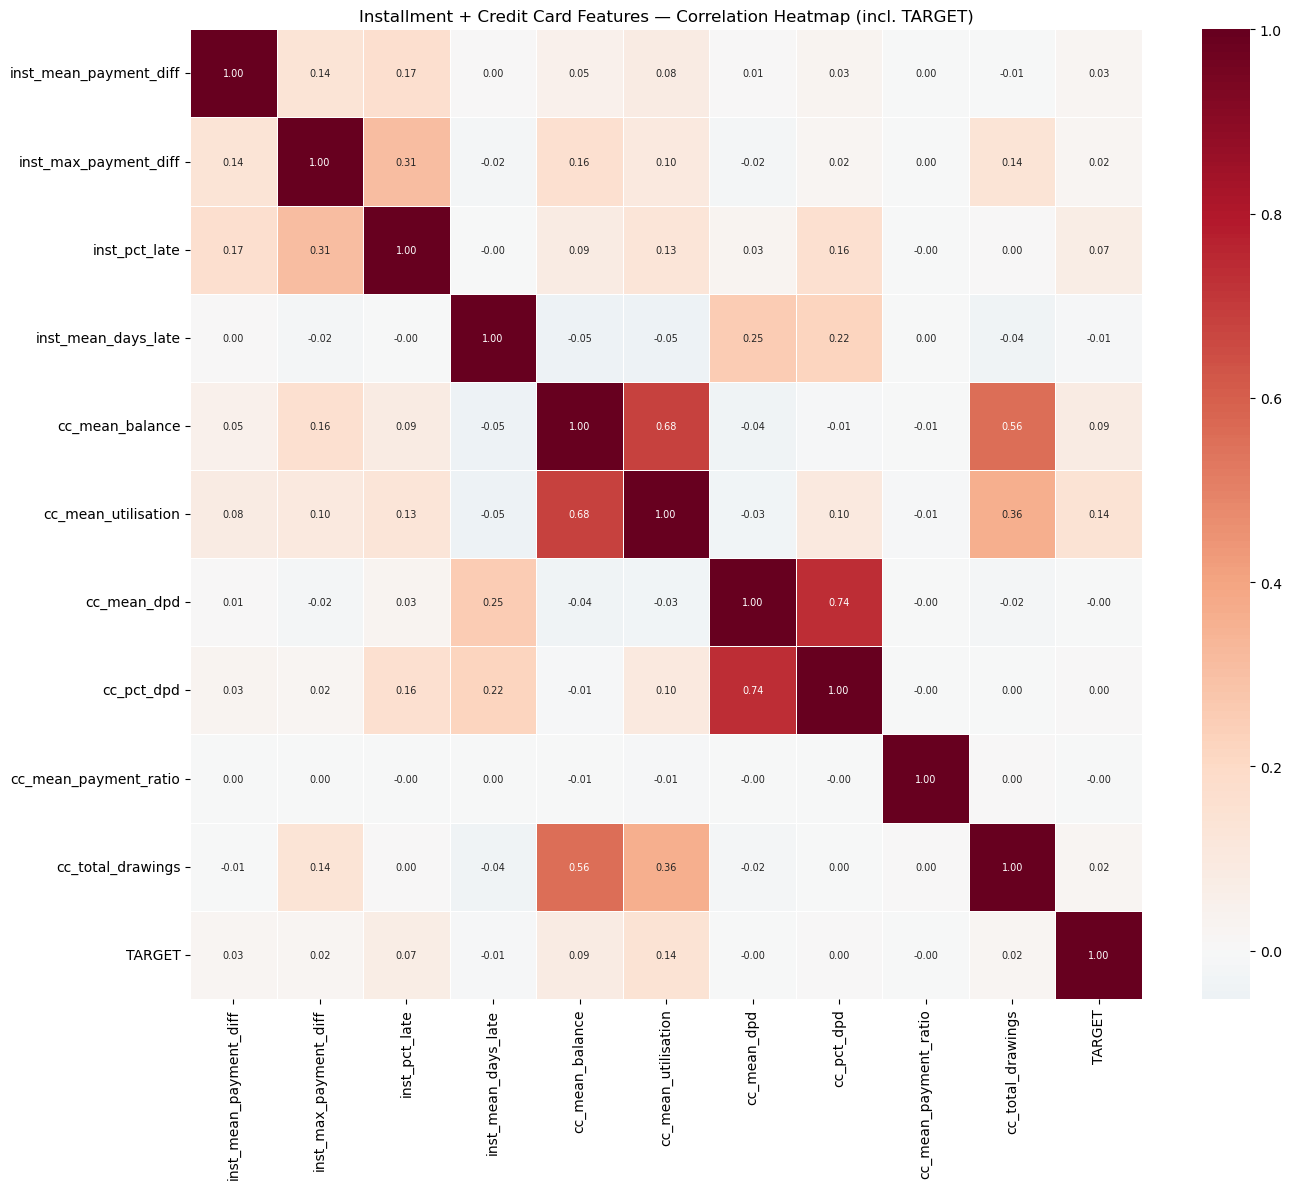

In [ ]:
# Combined features correlation heatmap 
combined = (
    inst_df[['SK_ID_CURR'] + inst_plot_cols]
    .merge(cc_df[['SK_ID_CURR'] + cc_plot_cols], on='SK_ID_CURR', how='outer')
    .merge(train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner')
)

all_feat_cols = inst_plot_cols + cc_plot_cols + ['TARGET']
corr_matrix   = combined[all_feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Installment + Credit Card Features — Correlation Heatmap (incl. TARGET)', fontsize=12)
plt.tight_layout()
plt.show()

### Key Takeaways

**Installments Payments**
- Defaulters consistently **underpay** (`inst_mean_payment_diff` higher) and **pay later** (`inst_pct_late`, `inst_mean_days_late` higher).
- `inst_pct_late` tends to be the strongest single signal. The fraction of instalments paid late captures chronic lateness better than the average lag alone.

**Credit Card Balance**
- Higher **credit utilisation** correlates with default; the 80–100 % bucket shows markedly elevated default rates.
- `cc_mean_payment_ratio` (payment vs. minimum due) is negatively correlated with default: applicants who pay well above the minimum are safer credits.

**Feature Engineering candidates for modelling**
| Feature | Direction |
|---|---|
| `inst_pct_late` | ↑ risk |
| `inst_mean_days_late` | ↑ risk |
| `inst_mean_payment_diff` | ↑ risk |
| `cc_pct_dpd` | ↑ risk |
| `cc_mean_utilisation` | ↑ risk |
| `cc_mean_payment_ratio` | ↓ risk |